#OIL AGENTIC TRADING SYSTEM

---

##0.REFERENCE

https://chatgpt.com/share/69f5f973-c940-83e8-a567-0710f2ebf0c6

##1.CONTEXT

**Introduction**

This notebook presents a complete tutorial for building an agentic oil futures trading system under a governance-first design philosophy. The objective is not merely to create a trading signal, generate a portfolio, or produce a synthetic backtest. The objective is to show how a serious financial research workflow can be organized when multiple agents cooperate under explicit controls, documentation standards, risk boundaries, and human-review requirements. In that sense, the notebook is not simply about oil futures. It is about how to design an auditable trading research organization in miniature.

The system uses synthetic oil futures data. This choice is deliberate. Synthetic data allow us to create a controlled market laboratory where the hidden structure of the world is known to the designer but not directly available to the analytical agents. This is pedagogically powerful because it allows the notebook to teach the difference between the true regime, the observable data, the inferred regime, and the trading decision. In live financial markets, the true regime is never handed to the analyst. Traders and models must infer whether the market is calm, stressed, oversupplied, inventory-driven, momentum-driven, or liquidity-constrained from imperfect evidence. The notebook recreates that challenge in a simplified but structured way.

The synthetic futures curve contains at least five contracts with different maturities: one-month, two-month, three-month, six-month, and twelve-month oil futures. This is important because futures trading is naturally a term-structure problem. Oil is not represented by one price alone. The front end of the curve can respond sharply to immediate supply disruptions, storage bottlenecks, delivery pressure, and short-term demand shocks. The longer end of the curve may reflect broader macro expectations, inventory conditions, future supply assumptions, and longer-horizon risk premia. A system that treats all maturities as interchangeable misses the central economic structure of futures trading.

The notebook creates three synthetic regimes. The first is a normal or balanced regime, where volatility is moderate and the curve behaves in a relatively stable way. The second is a contango or inventory-pressure regime, where longer maturities may trade at a premium to the front end and the curve may signal oversupply or storage pressure. The third is a stress or supply-shock regime, where volatility rises and the front end of the curve may react strongly to scarcity. These regimes are not intended to be a complete theory of oil markets. They are designed to provide a clear educational structure for understanding regime-aware trading.

The system is built using LangGraph. LangGraph is useful here because the workflow is not a single linear calculation. It is a stateful graph of agents. Each agent reads from a shared state, performs a specific role, writes its result back to the state, and leaves behind an audit artifact. This makes the workflow more realistic from an institutional perspective. In a financial organization, a trading strategy is not normally approved because one model generated a signal. Data teams, quantitative researchers, portfolio managers, risk managers, execution specialists, model validators, and investment committees all play distinct roles. This notebook mirrors that structure through software agents.

The first agent creates the synthetic data. This agent is responsible for producing the futures prices, returns, curve features, volatility measures, momentum measures, and hidden regime path. The second agent evaluates data quality. It checks whether the generated data are complete, coherent, and usable for downstream analysis. This is a crucial governance step because weak data can contaminate every later result. A profitable backtest based on defective data is not evidence of a good strategy. It is evidence of poor controls.

The HMM Regime Detection Agent then attempts to infer the current market regime from observable features. It does not receive the true hidden regime directly. Instead, it uses returns, curve slopes, volatility, and momentum to estimate latent states. The resulting regime label is not treated as truth. It is treated as a model output that must be interpreted, documented, and used with caution. This distinction is central to governance-first finance. A regime model can be useful, but it can also become dangerous if downstream agents treat its label as certain.

The notebook then introduces one contract valuation agent per futures maturity. This is one of the most important design choices in the system. Each contract agent evaluates its own maturity, reads the detected regime, considers valuation evidence, reviews momentum and volatility, and generates a contract-specific signal. In the enhanced version of the notebook, these contract agents are LLM-backed. This means that each contract agent has a quantitative evidence layer and a language-model reasoning layer. The quantitative layer computes structured evidence such as price, fair-value proxy, value gap, momentum, volatility, and deterministic signal. The LLM layer reads this evidence, interprets it professionally, writes a contract-level memo, flags risks, and may adjust the recommendation within governed boundaries.

This hybrid design is important. The LLM is not asked to invent numbers. It is not asked to hallucinate market facts. It is asked to reason over structured evidence generated by the notebook. That is the appropriate role for a language model in a governed financial workflow. It helps interpret, explain, challenge, and communicate. It does not replace data, valuation, risk control, or human approval. The notebook also records whether the LLM was successfully called, whether the JSON response was parsed correctly, whether a fallback was used, and whether the output remains unverified. This is essential for auditability.

After the contract agents produce their views, the Committee Coordinator Agent aggregates their recommendations. This agent receives the signals from all maturities and converts them into a preliminary long-short allocation. However, this is not yet an approved portfolio. The coordinator expresses the research view; it does not control final capital deployment. This distinction reflects real institutional practice. A research recommendation is not the same as a risk-approved allocation.

The Capital and Risk Allocation Agent then applies constraints. It enforces maximum gross exposure, maximum net exposure, maximum individual contract weight, and volatility scaling. This agent may reduce, clip, or reshape the coordinator’s proposal. It represents the principle that capital allocation must be governed by risk policy, not only by model conviction. A model may want to be aggressive. The risk system may refuse. That refusal is not a weakness. It is the discipline that makes the system institutionally credible.

The Stress Risk Agent then challenges the allocation under adverse scenarios. Oil futures can reprice violently when regimes shift. A supply shock can lift the front end. An inventory glut can deepen contango. A demand crash can push the entire curve lower. A regime flip can damage a position that looked balanced under recent conditions. The stress agent tests these possibilities before the system presents its result to the committee. This is a central lesson of the notebook: a strategy can look attractive in a base case and still be unacceptable under stress.

The Execution Agent adds transaction costs and slippage. This step teaches another essential trading lesson: paper performance is not the same as implementable performance. A strategy must survive the cost of trading. Even in a synthetic environment, it is important to include cost drag so that the notebook does not train the user to admire frictionless results. The Model Evaluation Agent then computes performance and governance diagnostics, including final equity, drawdown, hit rate, and whether all required controls were completed.

The Audit Bundle Agent creates the institutional memory of the run. It saves manifests, logs, JSON reports, CSV outputs, figures, and final summaries. Without this audit bundle, the notebook would merely produce temporary results. With it, the run becomes reviewable. A human reviewer can inspect the configuration, the agent outputs, the LLM memos, the allocation, the stress tests, and the final report. Finally, the Committee Report Agent writes a readable narrative for decision makers. This report may use Claude, but the report remains based on structured evidence and must preserve the warning that the system is synthetic and not verified.

The core principle of the notebook is simple: the model proposes, the risk layer constrains, the stress layer challenges, the audit layer documents, and the human committee remains accountable. This is the governance-first approach to agentic trading. The point is not to pretend that agents magically solve oil futures trading. The point is to show how agents can be organized so that every step is explicit, reviewable, constrained, and teachable.

##2.CODE AND IMPLEMENTATION

###2.1.LIBRARIES AND ENVIRONMENT

**Cell 1 Explanation**

Cell 1 prepares the entire notebook environment. It installs the required Python packages, imports the libraries, defines the main configuration, creates the folders where outputs will be saved, initializes the Claude client, and sets up helper functions for saving files and calling the language model.

This cell is important because the whole project depends on reproducibility. A governance-first trading system should not begin with hidden settings or informal assumptions. It should begin by clearly defining the run identifier, the random seed, the list of contracts, the number of synthetic trading days, the capital amount, the exposure limits, the transaction cost assumptions, the slippage assumptions, and the name of the Claude model. These settings become part of the audit record.

The cell also loads the Anthropic API key from the hidden Colab secrets section. The key is expected to be stored as `ANTHROPIC_API_KEY`. If the key is not available, the notebook does not immediately fail. Instead, it creates a fallback path so that the notebook remains runnable. This is important because a governed workflow should disclose when the LLM is unavailable rather than silently pretending that the LLM was used.

The most important improvement in this version of Cell 1 is the governance wrapper around Claude calls. The notebook does not simply call Claude and assume success. It records whether the call succeeded, whether the client was available, whether an API error occurred, and whether the returned text could be parsed as JSON. This matters because the contract valuation agents rely on structured LLM responses. If the LLM fails or produces unusable output, the notebook uses a deterministic fallback and records that fallback in the audit trail.

Cell 1 also creates the run manifest. The manifest is a formal record of the run. It contains the run ID, timestamp, configuration hash, configuration settings, Claude model, whether the Claude client is available, and whether LLM-backed contract agents are enabled. This manifest is saved to the audit bundle. In practical terms, it is the identity card of the notebook run.

In simple terms, Cell 1 answers the question: “What environment are we running, under what assumptions, with what model, and with what governance controls?” Without this cell, the rest of the notebook would lack a stable foundation.

In [11]:
# ============================================================
# CELL 1 — INSTALLS, IMPORTS, CONFIGURATION, FOLDERS, CLAUDE CLIENT
# ============================================================

!pip -q install langgraph langchain anthropic hmmlearn scikit-learn pandas numpy matplotlib networkx pydantic requests

import os
import json
import math
import shutil
import hashlib
import warnings
from dataclasses import dataclass
from typing import TypedDict, Dict, List, Any, Optional, Tuple
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from pydantic import BaseModel, Field
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from hmmlearn.hmm import GaussianHMM

from langgraph.graph import StateGraph, START, END

warnings.filterwarnings("ignore")

# ----------------------------
# Colab-safe secret loading
# ----------------------------
try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")

# ----------------------------
# Claude client
# ----------------------------
try:
    import anthropic
    claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None
except Exception:
    claude_client = None

CLAUDE_MODEL = "claude-haiku-4-5-20251001"

# ----------------------------
# Reproducibility and folders
# ----------------------------
SEED = 42
np.random.seed(SEED)

RUN_ID = datetime.now(timezone.utc).strftime("oil_agentic_run_%Y%m%dT%H%M%SZ")

BASE_DIR = "/content/agentic_oil_futures_trading"
DATA_DIR = f"{BASE_DIR}/data"
ARTIFACT_DIR = f"{BASE_DIR}/artifacts"
AUDIT_DIR = f"{BASE_DIR}/audit_bundle"
REPORT_DIR = f"{BASE_DIR}/reports"
FIG_DIR = f"{BASE_DIR}/figures"

for d in [BASE_DIR, DATA_DIR, ARTIFACT_DIR, AUDIT_DIR, REPORT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ----------------------------
# Core configuration
# ----------------------------
CONFIG = {
    "run_id": RUN_ID,
    "seed": SEED,
    "asset_class": "Synthetic Oil Futures",
    "contracts": ["CL_1M", "CL_2M", "CL_3M", "CL_6M", "CL_12M"],
    "n_days": 756,
    "initial_capital": 10_000_000,
    "max_gross_exposure": 1.50,
    "max_net_exposure": 0.25,
    "max_contract_weight_abs": 0.35,
    "annualization": 252,
    "transaction_cost_bps": 2.0,
    "slippage_bps": 3.0,
    "hmm_states": 3,
    "regime_names": {
        0: "Normal / Balanced",
        1: "Contango / Inventory Pressure",
        2: "Stress / Supply Shock"
    },
    "valuation_lookback": 63,
    "momentum_lookback": 21,
    "vol_lookback": 21,
    "target_daily_vol": 0.008,
    "claude_model": CLAUDE_MODEL,
    "llm_contract_agents_enabled": True,
    "llm_contract_json_required": True,
    "llm_temperature": 0.2,
    "governance_first_principles": [
        "Synthetic data only; no investment advice.",
        "Every agent produces explicit artifacts.",
        "LLM outputs are interpretations of structured evidence, not verified facts.",
        "Model output is not considered verified unless reviewed by a human committee.",
        "The audit bundle must include configuration, assumptions, limitations, metrics, and logs.",
        "Allocation is constrained before execution.",
        "Risk stress testing is mandatory before committee reporting."
    ]
}

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def stable_hash(obj: Any) -> str:
    payload = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

CONFIG_HASH = stable_hash(CONFIG)

def save_json(obj: Any, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)

def save_text(text: str, path: str):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

# ============================================================
# LLM HELPERS WITH GOVERNANCE STATUS
# ============================================================

def call_claude_text(prompt: str, max_tokens: int = 1500) -> Dict[str, Any]:
    """
    Calls Claude and returns a governed response dictionary.

    This function never crashes the notebook. If Claude is unavailable,
    the caller receives a fallback status and can decide how to proceed.
    """

    if claude_client is None:
        return {
            "llm_call_status": "fallback_used_no_client",
            "model": CLAUDE_MODEL,
            "text": "Claude client was not available. Deterministic fallback used.",
            "error": None
        }

    try:
        msg = claude_client.messages.create(
            model=CLAUDE_MODEL,
            max_tokens=max_tokens,
            temperature=CONFIG["llm_temperature"],
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )

        text = msg.content[0].text if msg.content else ""

        return {
            "llm_call_status": "success",
            "model": CLAUDE_MODEL,
            "text": text,
            "error": None
        }

    except Exception as e:
        return {
            "llm_call_status": "fallback_used_api_error",
            "model": CLAUDE_MODEL,
            "text": "Claude call failed. Deterministic fallback used.",
            "error": repr(e)
        }


def strip_code_fences(text: str) -> str:
    """
    Removes common markdown code fences from an LLM response.
    """

    cleaned = text.strip()

    if cleaned.startswith("```json"):
        cleaned = cleaned[len("```json"):].strip()

    if cleaned.startswith("```"):
        cleaned = cleaned[len("```"):].strip()

    if cleaned.endswith("```"):
        cleaned = cleaned[:-len("```")].strip()

    return cleaned


def extract_largest_json_object(text: str) -> Dict[str, Any]:
    """
    Robust JSON extraction:
    - strips code fences if present
    - scans for balanced JSON objects
    - parses the largest valid-looking object
    """

    cleaned = strip_code_fences(text)

    best_candidate = None

    for start in range(len(cleaned)):
        if cleaned[start] != "{":
            continue

        depth = 0
        in_string = False
        escape = False

        for end in range(start, len(cleaned)):
            ch = cleaned[end]

            if escape:
                escape = False
                continue

            if ch == "\\":
                escape = True
                continue

            if ch == '"':
                in_string = not in_string
                continue

            if in_string:
                continue

            if ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1

            if depth == 0:
                candidate = cleaned[start:end + 1]
                if best_candidate is None or len(candidate) > len(best_candidate):
                    best_candidate = candidate
                break

    if best_candidate is None:
        raise ValueError("No balanced JSON object found in Claude response.")

    return json.loads(best_candidate)


def call_claude_json(prompt: str, max_tokens: int = 2000) -> Dict[str, Any]:
    """
    Calls Claude and requires a parseable JSON object.

    Returns:
    - llm_call_status
    - json_parse_status
    - parsed object if successful
    - raw_text if available
    - error if relevant
    """

    result = call_claude_text(prompt, max_tokens=max_tokens)

    if result["llm_call_status"] != "success":
        return {
            "llm_call_status": result["llm_call_status"],
            "model": result["model"],
            "json_parse_status": "not_attempted",
            "parsed": None,
            "raw_text": result.get("text", ""),
            "error": result.get("error")
        }

    try:
        parsed = extract_largest_json_object(result["text"])
        return {
            "llm_call_status": "success",
            "model": result["model"],
            "json_parse_status": "success",
            "parsed": parsed,
            "raw_text": result["text"],
            "error": None
        }

    except Exception as e:
        return {
            "llm_call_status": "success_but_json_parse_failed",
            "model": result["model"],
            "json_parse_status": "failed",
            "parsed": None,
            "raw_text": result["text"],
            "error": repr(e)
        }


# Backward-compatible helper for the Committee Report Agent in Cell 7
def call_claude(prompt: str, max_tokens: int = 1500) -> str:
    result = call_claude_text(prompt, max_tokens=max_tokens)
    return result["text"]


# ----------------------------
# Manifest
# ----------------------------
manifest = {
    "run_id": RUN_ID,
    "created_at_utc": utc_now_iso(),
    "config_hash": CONFIG_HASH,
    "config": CONFIG,
    "environment_note": "Colab notebook; synthetic data; governance-first tutorial.",
    "llm_engine": {
        "provider": "Anthropic",
        "model": CLAUDE_MODEL,
        "client_available": claude_client is not None,
        "contract_agents_use_llm": CONFIG["llm_contract_agents_enabled"]
    },
    "verification_status": "Not verified; requires human committee review."
}

save_json(manifest, f"{AUDIT_DIR}/run_manifest.json")

print("Environment ready.")
print(f"RUN_ID: {RUN_ID}")
print(f"CONFIG_HASH: {CONFIG_HASH}")
print(f"Claude client available: {claude_client is not None}")
print(f"Claude model: {CLAUDE_MODEL}")
print(f"LLM-backed contract agents enabled: {CONFIG['llm_contract_agents_enabled']}")

Environment ready.
RUN_ID: oil_agentic_run_20260502T130645Z
CONFIG_HASH: c1d0c9a546e6b5dd98046daa8fea223cc203d977903ff884fec9ad8cee8b2fbb
Claude client available: True
Claude model: claude-haiku-4-5-20251001
LLM-backed contract agents enabled: True


### 2.2.GOVERNANCE SCHEMAS STATE AND AUDIT LOGGING UTILITIES

**Cell 2 Explanation**

Cell 2 defines the governance structure of the notebook. It creates the formal state object used by the LangGraph workflow, defines the artifact format, and provides logging utilities that every agent can use. This cell does not trade, model, or evaluate anything directly. Its role is to create the institutional memory of the system.

The most important idea in this cell is the shared state. In a LangGraph workflow, agents communicate by reading from and writing to a common state. This state contains the configuration, logs, artifacts, data, regime reports, contract signals, allocations, stress results, execution reports, evaluation metrics, audit reports, and final committee report. Instead of passing disconnected variables from one function to another, the notebook keeps a structured record of what has happened.

This matters for governance. In a simple trading notebook, it is easy to lose track of how a result was produced. A variable may be overwritten, a parameter may be changed, or an intermediate step may disappear. In this notebook, each agent writes its output into the state and creates an artifact. That makes the workflow easier to inspect and reproduce.

Cell 2 also defines the artifact structure. Each artifact includes the agent name, timestamp, purpose, input summary, output summary, limitations, verification status, and hash. This is a professional design choice. The artifact is not just a log message. It is a formal record of what the agent did and what its output means. The verification status is especially important because the system is synthetic and educational. The notebook repeatedly states that outputs are not verified and require human review.

The cell also includes utility functions for appending logs, creating artifacts, writing logs to disk, and normalizing portfolio weights under exposure limits. These utilities are used later by the agents. For example, when a contract agent finishes its work, it can append a log and create an artifact using the same standardized format as all other agents.

In simple terms, Cell 2 answers the question: “How will the system remember what every agent did?” It gives the notebook an audit spine. Without this cell, the project would be a collection of calculations. With this cell, it becomes a governed workflow.

In [2]:
# ============================================================
# CELL 2 — GOVERNANCE SCHEMAS, STATE, AUDIT LOGGING UTILITIES
# ============================================================

class AgentArtifact(BaseModel):
    agent_name: str
    created_at_utc: str
    purpose: str
    inputs_summary: Dict[str, Any] = Field(default_factory=dict)
    outputs_summary: Dict[str, Any] = Field(default_factory=dict)
    limitations: List[str] = Field(default_factory=list)
    verification_status: str = "Not verified"
    hash: Optional[str] = None

class OilTradingState(TypedDict, total=False):
    config: Dict[str, Any]
    logs: List[Dict[str, Any]]
    artifacts: Dict[str, Any]

    data: pd.DataFrame
    true_regimes: pd.Series
    data_quality_report: Dict[str, Any]

    hmm_report: Dict[str, Any]
    detected_regimes: pd.Series

    contract_signals: Dict[str, pd.DataFrame]
    latest_contract_views: Dict[str, Dict[str, Any]]

    committee_recommendation: Dict[str, Any]
    capital_risk_allocation: Dict[str, Any]
    final_allocation: pd.DataFrame

    stress_report: Dict[str, Any]
    execution_report: Dict[str, Any]
    executed_portfolio: pd.DataFrame

    evaluation_report: Dict[str, Any]
    audit_report: Dict[str, Any]
    committee_report: str

def append_log(state: OilTradingState, agent: str, event: str, payload: Optional[Dict[str, Any]] = None) -> OilTradingState:
    logs = state.get("logs", [])
    logs.append({
        "timestamp_utc": utc_now_iso(),
        "agent": agent,
        "event": event,
        "payload": payload or {}
    })
    state["logs"] = logs
    return state

def create_artifact(
    state: OilTradingState,
    agent_name: str,
    purpose: str,
    inputs_summary: Dict[str, Any],
    outputs_summary: Dict[str, Any],
    limitations: List[str]
) -> OilTradingState:

    artifact = AgentArtifact(
        agent_name=agent_name,
        created_at_utc=utc_now_iso(),
        purpose=purpose,
        inputs_summary=inputs_summary,
        outputs_summary=outputs_summary,
        limitations=limitations,
        verification_status="Not verified"
    )

    artifact_dict = artifact.model_dump()
    artifact_dict["hash"] = stable_hash(artifact_dict)

    artifacts = state.get("artifacts", {})
    artifacts[agent_name] = artifact_dict
    state["artifacts"] = artifacts

    path = f"{AUDIT_DIR}/{agent_name}.json"
    save_json(artifact_dict, path)

    return state

def write_logs_to_disk(state: OilTradingState):
    save_json(state.get("logs", []), f"{AUDIT_DIR}/agent_logs.json")

def normalize_to_bounds(raw_scores: pd.Series, max_abs_weight: float, max_gross: float, max_net: float) -> pd.Series:
    """
    Converts raw signals into long-short weights under simple governance constraints:
    - individual absolute weight cap
    - gross exposure cap
    - net exposure cap by de-meaning and clipping
    """
    scores = raw_scores.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    if scores.abs().sum() == 0:
        return pd.Series(0.0, index=scores.index)

    weights = scores / scores.abs().sum()
    weights = weights * min(max_gross, 1.0)

    weights = weights.clip(lower=-max_abs_weight, upper=max_abs_weight)

    # Reduce net exposure by de-meaning
    weights = weights - weights.mean()

    # Re-scale gross after de-meaning
    gross = weights.abs().sum()
    if gross > max_gross and gross > 0:
        weights = weights * (max_gross / gross)

    # Force net exposure bound
    net = weights.sum()
    if abs(net) > max_net:
        weights = weights - (net / len(weights))

    weights = weights.clip(lower=-max_abs_weight, upper=max_abs_weight)

    return weights

initial_state: OilTradingState = {
    "config": CONFIG,
    "logs": [],
    "artifacts": {}
}

print("Governance schemas and LangGraph state are ready.")

Governance schemas and LangGraph state are ready.


###2.3.SYNTHETIC DATA AGENT


**Cell 3 Explanation**

Cell 3 creates the synthetic oil futures data. This is the first true agent in the workflow: the Synthetic Data Agent. Its job is to build a controlled market environment with multiple oil futures contracts and three hidden regimes. The data are synthetic, meaning they are generated by the notebook rather than downloaded from a market data provider.

The cell creates a sequence of business days and then generates a hidden regime path. The regimes represent normal market conditions, contango or inventory pressure, and stress or supply shock. These regimes are persistent, meaning the market tends to remain in the same state for some time before transitioning. This is more realistic than making the regime change randomly every day without memory.

The agent then creates a synthetic spot price proxy. The spot proxy behaves differently depending on the regime. In normal conditions, volatility is moderate. In contango or inventory pressure, the market may behave differently because the curve reflects oversupply or storage effects. In stress, volatility is higher and jumps can occur. This gives the later HMM agent something meaningful to detect.

After the spot proxy is created, the agent generates five futures contracts: one-month, two-month, three-month, six-month, and twelve-month. Each contract is linked to the spot proxy but adjusted by maturity and regime-specific curve behavior. This is important because oil futures trading is about the shape of the curve, not only the level of oil prices. The front end and long end can behave differently.

The cell also computes useful features, including front-month returns, curve slopes, rolling volatility, and momentum. These features are later used by the HMM Regime Detection Agent. The true hidden regime is also stored, but it is used only for synthetic evaluation. The trading agents do not receive it as market truth.

Finally, the generated data are saved to a CSV file, and the agent creates an audit artifact. The artifact explains what data were created, which contracts were included, and what limitations apply. The main limitation is that the data are synthetic and do not include real futures settlement mechanics, exchange rules, margin requirements, liquidity conditions, or roll schedules.

In simple terms, Cell 3 answers the question: “What synthetic oil futures world will the agents analyze?” It builds the laboratory for the rest of the notebook.

In [3]:
# ============================================================
# CELL 3 — SYNTHETIC DATA AGENT
# ============================================================

def synthetic_data_agent(state: OilTradingState) -> OilTradingState:
    """
    Creates synthetic oil futures data for five maturities under three regimes.

    Regimes:
    0: Normal / Balanced
    1: Contango / Inventory Pressure
    2: Stress / Supply Shock

    The agent generates:
    - spot proxy
    - 5 futures contracts
    - curve slope
    - returns
    - true regime labels
    """

    cfg = state["config"]
    n = cfg["n_days"]
    contracts = cfg["contracts"]

    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)

    # Markov transition matrix for three regimes
    transition = np.array([
        [0.94, 0.05, 0.01],
        [0.07, 0.89, 0.04],
        [0.08, 0.12, 0.80]
    ])

    regimes = np.zeros(n, dtype=int)
    regimes[0] = 0

    for t in range(1, n):
        regimes[t] = np.random.choice([0, 1, 2], p=transition[regimes[t - 1]])

    # Regime-specific daily dynamics
    drift = {
        0: 0.00015,
        1: -0.00005,
        2: 0.00045
    }

    vol = {
        0: 0.012,
        1: 0.016,
        2: 0.032
    }

    # Regime-specific futures curve shape
    # Normal: mildly backwardated
    # Contango: positive carry / upward curve
    # Stress: front contract spikes, backwardation steepens
    curve_slope = {
        0: -0.015,
        1: 0.035,
        2: -0.065
    }

    maturity_years = {
        "CL_1M": 1 / 12,
        "CL_2M": 2 / 12,
        "CL_3M": 3 / 12,
        "CL_6M": 6 / 12,
        "CL_12M": 1.0
    }

    spot = np.zeros(n)
    spot[0] = 75.0

    for t in range(1, n):
        r = regimes[t]
        shock = np.random.normal(drift[r], vol[r])

        # Occasional jump in stress regime
        if r == 2 and np.random.rand() < 0.04:
            shock += np.random.choice([1, -1]) * np.random.uniform(0.025, 0.075)

        spot[t] = max(20.0, spot[t - 1] * np.exp(shock))

    data = pd.DataFrame(index=dates)
    data["spot_proxy"] = spot
    data["true_regime"] = regimes

    for c in contracts:
        tau = maturity_years[c]
        contract_noise = np.random.normal(0, 0.004, size=n)
        contract_price = []

        for t in range(n):
            r = regimes[t]
            slope = curve_slope[r]
            convenience_yield_noise = np.random.normal(0, 0.003)
            futures_price = spot[t] * np.exp((slope + convenience_yield_noise) * tau + contract_noise[t])
            contract_price.append(max(15.0, futures_price))

        data[c] = contract_price

    # Features useful for regime detection
    data["front_return"] = data["CL_1M"].pct_change()
    data["curve_slope_12m_1m"] = np.log(data["CL_12M"] / data["CL_1M"])
    data["curve_slope_6m_1m"] = np.log(data["CL_6M"] / data["CL_1M"])
    data["front_vol_21d"] = data["front_return"].rolling(21).std()
    data["front_momentum_21d"] = data["CL_1M"].pct_change(21)

    for c in contracts:
        data[f"{c}_return"] = data[c].pct_change()

    data = data.dropna().copy()
    true_regimes = data["true_regime"].astype(int)

    path = f"{DATA_DIR}/synthetic_oil_futures.csv"
    data.to_csv(path)

    state["data"] = data
    state["true_regimes"] = true_regimes

    state = append_log(
        state,
        "synthetic_data_agent",
        "created_synthetic_oil_futures_data",
        {
            "rows": len(data),
            "contracts": contracts,
            "regimes": cfg["regime_names"],
            "path": path
        }
    )

    state = create_artifact(
        state,
        agent_name="synthetic_data_agent",
        purpose="Generate synthetic oil futures term structure data under three regimes.",
        inputs_summary={
            "n_days": n,
            "contracts": contracts,
            "seed": cfg["seed"]
        },
        outputs_summary={
            "rows": len(data),
            "columns": list(data.columns),
            "saved_to": path
        },
        limitations=[
            "Synthetic prices are not market data.",
            "Regime dynamics are pedagogical and simplified.",
            "No actual WTI futures settlement, roll calendar, liquidity, margin, or exchange constraint is modeled."
        ]
    )

    return state

# Local smoke test for this cell only
test_state = synthetic_data_agent(initial_state.copy())
display(test_state["data"].head())
print("Synthetic data agent is ready.")

,spot_proxy,true_regime,CL_1M,CL_2M,CL_3M,CL_6M,CL_12M,front_return,curve_slope_12m_1m,curve_slope_6m_1m,front_vol_21d,front_momentum_21d,CL_1M_return,CL_2M_return,CL_3M_return,CL_6M_return,CL_12M_return
2023-07-10,82.209171,1,82.436834,82.254529,82.351346,83.245578,84.982621,-0.025898,0.030414,0.009763,0.015627,0.100869,-0.025898,-0.029001,-0.027931,-0.033976,-0.031335
2023-07-11,82.575439,1,82.979839,83.335569,83.652379,83.931074,86.142024,0.006587,0.037400,0.011398,0.015632,0.103281,0.006587,0.013143,0.015799,0.008235,0.013643
2023-07-12,81.184807,1,81.343619,81.467131,82.260881,82.596775,83.641601,-0.019718,0.027859,0.015288,0.015693,0.053793,-0.019718,-0.022421,-0.016634,-0.015898,-0.029027
2023-07-13,80.517254,1,80.978315,80.379900,81.357800,82.234321,82.671858,-0.004491,0.020698,0.015391,0.015216,0.028108,-0.004491,-0.013346,-0.010978,-0.004388,-0.011594
2023-07-14,80.733290,1,80.964745,81.274431,81.442010,82.615600,83.853292,-0.000168,0.035055,0.020185,0.015209,0.029145,-0.000168,0.011129,0.001035,0.004636,0.014291


Synthetic data agent is ready.


###2.4.DATA QUALITY AGENT


**Cell 4 Explanation**

Cell 4 runs the Data Quality Agent. This agent checks whether the synthetic oil futures data are usable before the system allows downstream agents to rely on them. In a governance-first workflow, this step is essential. No matter how sophisticated the later agents may be, they should not act on data that are incomplete, incoherent, or mechanically defective.

The agent examines several basic but important issues. First, it checks for missing values. Missing values can distort returns, rolling volatility, momentum, curve slopes, and backtest results. Second, it checks for duplicate dates. Duplicate timestamps can create misleading calculations because the same day may be counted twice. Third, it checks whether any futures prices are non-positive. In this simplified tutorial, prices are expected to remain positive. If non-positive values appear, that would suggest a problem in the synthetic data generator.

The agent also checks for extreme returns. Extreme returns are not automatically wrong, especially because the synthetic data include stress regimes. However, extreme values should be counted and disclosed. If there are too many extreme returns, the synthetic environment may be unrealistically unstable. If there are no extreme movements at all, the environment may be too easy and may fail to test the strategy properly.

The agent also reviews regime balance. Since the synthetic data contain three regimes, the notebook checks how many observations belong to each regime. This is not done to give the answer key to the trading system. It is done to evaluate whether the synthetic laboratory is usable. If one regime barely appears, the model may not have enough examples to learn or test behavior under that state.

The output of the agent is a structured data quality report. It includes row counts, column names, missing values, duplicate dates, non-positive prices, extreme-return counts, regime counts, regime percentages, quality flags, and verification status. The report is saved to the audit bundle.

This cell teaches a very important lesson: data quality is not a technical detail. It is a governance control. A trading system that ignores data defects can produce attractive but meaningless results. The Data Quality Agent protects the rest of the workflow from inheriting silent problems.

In simple terms, Cell 4 answers the question: “Is the synthetic data good enough for the rest of the agents to use?”

In [4]:
# ============================================================
# CELL 4 — DATA QUALITY AGENT
# ============================================================

def data_quality_agent(state: OilTradingState) -> OilTradingState:
    """
    Evaluates whether the synthetic data is usable for the tutorial.
    It checks:
    - missing values
    - duplicate dates
    - non-positive prices
    - extreme returns
    - basic regime balance
    """

    data = state["data"].copy()
    cfg = state["config"]
    contracts = cfg["contracts"]

    missing = data.isna().sum().to_dict()
    duplicate_index_count = int(data.index.duplicated().sum())

    non_positive_prices = {
        c: int((data[c] <= 0).sum())
        for c in contracts
    }

    return_cols = [f"{c}_return" for c in contracts]
    extreme_returns = {
        c: int((data[f"{c}_return"].abs() > 0.15).sum())
        for c in contracts
    }

    regime_counts = data["true_regime"].value_counts().sort_index().to_dict()
    regime_percent = (data["true_regime"].value_counts(normalize=True).sort_index() * 100).round(2).to_dict()

    quality_flags = []

    if sum(missing.values()) > 0:
        quality_flags.append("Missing values detected.")

    if duplicate_index_count > 0:
        quality_flags.append("Duplicate timestamps detected.")

    if sum(non_positive_prices.values()) > 0:
        quality_flags.append("Non-positive futures prices detected.")

    if sum(extreme_returns.values()) > 10:
        quality_flags.append("Large number of extreme returns detected.")

    if min(regime_percent.values()) < 5:
        quality_flags.append("At least one regime is underrepresented.")

    if not quality_flags:
        quality_flags.append("No blocking data quality issue detected.")

    report = {
        "created_at_utc": utc_now_iso(),
        "rows": len(data),
        "columns": list(data.columns),
        "missing_values": missing,
        "duplicate_index_count": duplicate_index_count,
        "non_positive_prices": non_positive_prices,
        "extreme_returns_abs_gt_15pct": extreme_returns,
        "regime_counts": regime_counts,
        "regime_percent": regime_percent,
        "quality_flags": quality_flags,
        "verification_status": "Not verified; synthetic data quality requires human review."
    }

    state["data_quality_report"] = report

    save_json(report, f"{AUDIT_DIR}/data_quality_report.json")

    state = append_log(
        state,
        "data_quality_agent",
        "completed_data_quality_review",
        {
            "quality_flags": quality_flags,
            "rows": len(data)
        }
    )

    state = create_artifact(
        state,
        agent_name="data_quality_agent",
        purpose="Evaluate synthetic oil futures data quality before modeling.",
        inputs_summary={
            "rows": len(data),
            "contracts": contracts
        },
        outputs_summary={
            "quality_flags": quality_flags,
            "regime_percent": regime_percent
        },
        limitations=[
            "Data quality tests are necessary but not sufficient.",
            "Synthetic data can pass mechanical tests while still being unrealistic.",
            "No external vendor reconciliation is performed."
        ]
    )

    return state

# Local smoke test
test_state = data_quality_agent(test_state)
save_json(test_state["data_quality_report"], f"{AUDIT_DIR}/data_quality_report_smoke_test.json")
print(json.dumps(test_state["data_quality_report"], indent=2))

{
  "created_at_utc": "2026-05-02T12:52:00.378911+00:00",
  "rows": 735,
  "columns": [
    "spot_proxy",
    "true_regime",
    "CL_1M",
    "CL_2M",
    "CL_3M",
    "CL_6M",
    "CL_12M",
    "front_return",
    "curve_slope_12m_1m",
    "curve_slope_6m_1m",
    "front_vol_21d",
    "front_momentum_21d",
    "CL_1M_return",
    "CL_2M_return",
    "CL_3M_return",
    "CL_6M_return",
    "CL_12M_return"
  ],
  "missing_values": {
    "spot_proxy": 0,
    "true_regime": 0,
    "CL_1M": 0,
    "CL_2M": 0,
    "CL_3M": 0,
    "CL_6M": 0,
    "CL_12M": 0,
    "front_return": 0,
    "curve_slope_12m_1m": 0,
    "curve_slope_6m_1m": 0,
    "front_vol_21d": 0,
    "front_momentum_21d": 0,
    "CL_1M_return": 0,
    "CL_2M_return": 0,
    "CL_3M_return": 0,
    "CL_6M_return": 0,
    "CL_12M_return": 0
  },
  "duplicate_index_count": 0,
  "non_positive_prices": {
    "CL_1M": 0,
    "CL_2M": 0,
    "CL_3M": 0,
    "CL_6M": 0,
    "CL_12M": 0
  },
  "extreme_returns_abs_gt_15pct": {
    "CL_1

###2.5.HMM REGIME DETECTION AGENT

**Cell 5 Explanation**

Cell 5 runs the HMM Regime Detection Agent. This agent attempts to infer the current market regime from observable features in the synthetic oil futures data. It does not directly use the true hidden regime created by the Synthetic Data Agent. That is a crucial design choice. The agent must behave like a real market model: it sees market evidence, not the answer key.

The agent uses features such as front-month returns, curve slopes, rolling volatility, and momentum. These variables describe different aspects of the oil futures market. Returns show price movement. Curve slopes show the shape of the futures curve. Volatility shows uncertainty. Momentum shows recent directional pressure. Together, they provide a compact view of market conditions.

The agent fits a Gaussian hidden Markov model with three hidden states. The HMM tries to group observations into latent states based on the statistical behavior of the features. However, the raw hidden states produced by the HMM do not automatically mean “normal,” “contango,” or “stress.” They are simply statistical categories. The agent must map them into economic regimes.

The mapping is done by looking at state characteristics. For example, the hidden state with the highest volatility can be interpreted as the stress regime. The state with the strongest positive curve slope can be interpreted as the contango regime. The remaining state can be interpreted as normal or balanced. This mapping is documented because it is an assumption, not a fact.

The agent produces a regime report. The report includes the features used, the hidden-state mapping, summary statistics for each state, the latest detected regime, and a synthetic accuracy measure against the known hidden regime. The accuracy measure is useful for teaching because synthetic truth exists. In real markets, this accuracy would not be directly observable.

This cell teaches that regime detection is useful but uncertain. The detected regime should influence later agents, but it should not be treated as unquestionable truth. If the HMM misclassifies the market, the contract agents, allocation process, and stress behavior may all be affected.

In simple terms, Cell 5 answers the question: “What market regime does the model think we are in, based only on observable evidence?”

In [5]:
# ============================================================
# CELL 5 — HMM REGIME DETECTION AGENT
# ============================================================

def hmm_regime_agent(state: OilTradingState) -> OilTradingState:
    """
    Fits a Gaussian HMM to observable features and maps hidden states
    into economic regime descriptions.

    The agent communicates the detected regime to:
    - every contract valuation agent
    - the committee coordinator
    - the risk/stress agent
    """

    data = state["data"].copy()
    cfg = state["config"]

    feature_cols = [
        "front_return",
        "curve_slope_12m_1m",
        "curve_slope_6m_1m",
        "front_vol_21d",
        "front_momentum_21d"
    ]

    X_raw = data[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
    idx = X_raw.index

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    hmm = GaussianHMM(
        n_components=cfg["hmm_states"],
        covariance_type="full",
        n_iter=1000,
        random_state=cfg["seed"]
    )

    hmm.fit(X)
    hidden = hmm.predict(X)

    tmp = pd.DataFrame({
        "hidden_state": hidden,
        "front_vol_21d": data.loc[idx, "front_vol_21d"],
        "curve_slope_12m_1m": data.loc[idx, "curve_slope_12m_1m"],
        "front_momentum_21d": data.loc[idx, "front_momentum_21d"],
        "true_regime": data.loc[idx, "true_regime"]
    }, index=idx)

    # Economic mapping:
    # - highest volatility = stress
    # - highest curve slope = contango
    # - remaining = normal
    state_stats = tmp.groupby("hidden_state").agg({
        "front_vol_21d": "mean",
        "curve_slope_12m_1m": "mean",
        "front_momentum_21d": "mean"
    })

    stress_hidden = state_stats["front_vol_21d"].idxmax()
    contango_hidden = state_stats.drop(index=stress_hidden)["curve_slope_12m_1m"].idxmax()
    normal_hidden = [s for s in state_stats.index if s not in [stress_hidden, contango_hidden]][0]

    hidden_to_regime = {
        int(normal_hidden): 0,
        int(contango_hidden): 1,
        int(stress_hidden): 2
    }

    detected_regimes = pd.Series(hidden, index=idx).map(hidden_to_regime).astype(int)
    detected_regimes.name = "detected_regime"

    aligned_true = data.loc[idx, "true_regime"].astype(int)

    # HMM labels are unsupervised, but after economic mapping we can compute pedagogical accuracy.
    pedagogical_accuracy = float(accuracy_score(aligned_true, detected_regimes))

    hmm_report = {
        "created_at_utc": utc_now_iso(),
        "feature_columns": feature_cols,
        "hidden_to_regime_mapping": hidden_to_regime,
        "state_statistics": state_stats.reset_index().to_dict(orient="records"),
        "pedagogical_accuracy_against_synthetic_truth": pedagogical_accuracy,
        "latest_detected_regime": int(detected_regimes.iloc[-1]),
        "latest_detected_regime_name": cfg["regime_names"][int(detected_regimes.iloc[-1])],
        "verification_status": "Not verified; HMM regime classification requires model risk review."
    }

    state["detected_regimes"] = detected_regimes
    state["hmm_report"] = hmm_report

    out = data.loc[idx].copy()
    out["detected_regime"] = detected_regimes
    out.to_csv(f"{DATA_DIR}/synthetic_oil_futures_with_hmm_regimes.csv")

    save_json(hmm_report, f"{AUDIT_DIR}/hmm_regime_report.json")

    state = append_log(
        state,
        "hmm_regime_agent",
        "completed_hmm_regime_detection",
        {
            "latest_detected_regime": hmm_report["latest_detected_regime_name"],
            "pedagogical_accuracy": pedagogical_accuracy
        }
    )

    state = create_artifact(
        state,
        agent_name="hmm_regime_agent",
        purpose="Detect oil futures market regime using an unsupervised Gaussian HMM.",
        inputs_summary={
            "feature_columns": feature_cols,
            "hmm_states": cfg["hmm_states"]
        },
        outputs_summary={
            "latest_detected_regime": hmm_report["latest_detected_regime_name"],
            "pedagogical_accuracy_against_synthetic_truth": pedagogical_accuracy
        },
        limitations=[
            "HMM states are not inherently economic regimes; mapping requires interpretation.",
            "Accuracy is only possible because synthetic truth is known.",
            "No live market validation, no walk-forward production validation, and no parameter stability review is included."
        ]
    )

    return state

# Local smoke test
test_state = hmm_regime_agent(test_state)
print(json.dumps(test_state["hmm_report"], indent=2))

{
  "created_at_utc": "2026-05-02T12:52:38.076910+00:00",
  "feature_columns": [
    "front_return",
    "curve_slope_12m_1m",
    "curve_slope_6m_1m",
    "front_vol_21d",
    "front_momentum_21d"
  ],
  "hidden_to_regime_mapping": {
    "2": 0,
    "1": 1,
    "0": 2
  },
  "state_statistics": [
    {
      "hidden_state": 0,
      "front_vol_21d": 0.021450796193315993,
      "curve_slope_12m_1m": -0.035498286935995035,
      "front_momentum_21d": 0.05533461684221
    },
    {
      "hidden_state": 1,
      "front_vol_21d": 0.01950487530891261,
      "curve_slope_12m_1m": 0.03234429023855896,
      "front_momentum_21d": 0.01857585539287863
    },
    {
      "hidden_state": 2,
      "front_vol_21d": 0.014389578875737939,
      "curve_slope_12m_1m": -0.014459860823082005,
      "front_momentum_21d": 0.0014987300100700314
    }
  ],
  "pedagogical_accuracy_against_synthetic_truth": 0.8979591836734694,
  "latest_detected_regime": 0,
  "latest_detected_regime_name": "Normal / Balanced",


###2.6.CONTRACT VALUATION AND SIGNAL AGENTS

**Cell 6 Explanation**

Cell 6 defines the LLM-backed contract valuation and signal agents. This is one of the most important cells in the notebook because it gives each oil futures maturity its own hybrid agent. The system creates one agent for the one-month contract, one for the two-month contract, one for the three-month contract, one for the six-month contract, and one for the twelve-month contract.

Each contract agent has two layers. The first layer is quantitative. It computes structured evidence from the synthetic data. This includes the latest price, a fair-value proxy, the value gap between fair value and price, momentum, volatility, the detected regime, a deterministic signal score, and a deterministic recommendation. This quantitative layer ensures that the agent is grounded in data rather than free-form language.

The second layer is the LLM reasoning layer. Claude receives the structured evidence and writes a professional contract-level interpretation in strict JSON format. The LLM evaluates whether the deterministic signal makes sense, explains the valuation evidence, interprets the regime, discusses momentum and volatility, flags risks, assigns confidence, and may adjust the signal score or recommendation. This is the key correction from the earlier version of the notebook. The contract agents are no longer purely hard-coded; they actually call the LLM.

The cell includes strong governance controls around the LLM call. The agent records whether Claude was called successfully, whether the response was valid JSON, whether parsing succeeded, and whether a fallback was used. If the LLM is unavailable or returns unusable output, the notebook does not crash. Instead, it retains the deterministic signal and clearly records that a fallback was used. This is important because a governed system should fail transparently rather than silently.

Each contract agent saves two important outputs. First, it saves a CSV file with the contract signal history. Second, it saves a JSON memo with the LLM interpretation. The memo includes the recommendation, confidence level, valuation assessment, regime interpretation, risk flags, committee summary, and verification status.

This cell teaches the proper role of LLMs in financial agents. The LLM is not inventing market data. It is interpreting structured evidence. It is not approving trades. It is producing an auditable memo that remains subject to downstream risk controls and human review.

In simple terms, Cell 6 answers the question: “What does each contract agent think about its futures maturity, and how does Claude interpret the evidence?”

In [12]:
# ============================================================
# CELL 6 — LLM-BACKED CONTRACT VALUATION AND SIGNAL AGENTS
# ============================================================

def compute_contract_quant_view(
    data: pd.DataFrame,
    detected_regimes: pd.Series,
    contract: str,
    cfg: Dict[str, Any]
) -> pd.DataFrame:
    """
    Quantitative evidence layer for each contract agent.

    This layer computes:
    - price
    - fair value proxy
    - value gap
    - momentum
    - volatility
    - detected regime
    - deterministic signal score
    - deterministic discrete signal

    The LLM-backed contract agent then reviews this evidence,
    writes a professional valuation memo, and may adjust the signal.
    """

    lookback = cfg["valuation_lookback"]
    mom_lb = cfg["momentum_lookback"]
    vol_lb = cfg["vol_lookback"]

    df = data.loc[detected_regimes.index].copy()
    df["detected_regime"] = detected_regimes

    price = df[contract]
    front = df["CL_1M"]

    # Relative basis against the front contract
    basis = np.log(price / front)
    rolling_basis = basis.rolling(lookback).mean()

    # Simple regime adjustment
    regime_adjustment = df["detected_regime"].map({
        0: 0.00,
        1: -0.01,
        2: 0.015
    }).astype(float)

    fair_value_proxy = front * np.exp(
        rolling_basis.fillna(basis.expanding().mean()) + regime_adjustment
    )

    value_gap = np.log(fair_value_proxy / price)
    momentum = price.pct_change(mom_lb)
    vol = price.pct_change().rolling(vol_lb).std()

    deterministic_signal_score = (
        0.55 * value_gap.rank(pct=True).sub(0.5) +
        0.35 * momentum.rank(pct=True).sub(0.5) -
        0.10 * vol.rank(pct=True).fillna(0.5)
    )

    # Regime-specific deterministic adjustments
    # Longer maturities are penalized in contango.
    if contract in ["CL_6M", "CL_12M"]:
        deterministic_signal_score = deterministic_signal_score - 0.10 * (
            df["detected_regime"] == 1
        ).astype(float)

    # Short maturities are rewarded during stress/supply-shock regimes.
    if contract in ["CL_1M", "CL_2M"]:
        deterministic_signal_score = deterministic_signal_score + 0.10 * (
            df["detected_regime"] == 2
        ).astype(float)

    deterministic_discrete_signal = pd.cut(
        deterministic_signal_score,
        bins=[-np.inf, -0.15, 0.15, np.inf],
        labels=["SHORT", "HOLD", "LONG"]
    )

    out = pd.DataFrame({
        "price": price,
        "fair_value_proxy": fair_value_proxy,
        "value_gap": value_gap,
        "momentum": momentum,
        "volatility": vol,
        "detected_regime": df["detected_regime"],
        "deterministic_signal_score": deterministic_signal_score,
        "deterministic_discrete_signal": deterministic_discrete_signal.astype(str)
    }, index=df.index)

    return out.dropna()


def deterministic_contract_fallback(
    contract: str,
    latest_quant_view: Dict[str, Any],
    cfg: Dict[str, Any],
    reason: str
) -> Dict[str, Any]:
    """
    Fallback used when Claude is unavailable or JSON parsing fails.
    The notebook remains runnable and the fallback is disclosed.
    """

    signal = latest_quant_view["deterministic_discrete_signal"]
    score = float(latest_quant_view["deterministic_signal_score"])
    regime_id = int(latest_quant_view["detected_regime"])
    regime_name = cfg["regime_names"][regime_id]

    return {
        "contract": contract,
        "llm_recommendation": signal,
        "llm_adjusted_signal_score": score,
        "confidence": "LOW",
        "valuation_assessment": (
            "Deterministic fallback used. The LLM-backed contract evaluation "
            "was unavailable or could not be parsed, so the agent retained the "
            "quantitative signal."
        ),
        "regime_interpretation": (
            f"The detected regime was {regime_name}. No LLM interpretation was available."
        ),
        "momentum_interpretation": (
            "Momentum was interpreted mechanically through the deterministic signal layer."
        ),
        "volatility_interpretation": (
            "Volatility was interpreted mechanically through the deterministic signal layer."
        ),
        "agreement_with_deterministic_signal": "AGREE",
        "reason_for_any_adjustment": (
            "No adjustment was made because the LLM reasoning layer was unavailable."
        ),
        "risk_flags": [
            "LLM contract reasoning unavailable or unusable.",
            reason,
            "Recommendation not verified.",
            "Human review required."
        ],
        "committee_summary": (
            f"{contract}: deterministic fallback retained {signal} recommendation "
            f"with score {score:.4f}. The output is not verified."
        ),
        "verification_status": "Not verified; deterministic fallback used."
    }


def repair_contract_llm_json(
    parsed: Dict[str, Any],
    contract: str,
    latest_quant_view: Dict[str, Any]
) -> Dict[str, Any]:
    """
    Minimal schema repair and normalization for LLM contract output.
    This prevents small formatting defects from breaking the notebook.
    """

    allowed_signals = {"LONG", "HOLD", "SHORT"}
    allowed_confidence = {"LOW", "MEDIUM", "HIGH"}
    allowed_agreement = {"AGREE", "PARTIAL", "DISAGREE"}

    repaired = dict(parsed)

    repaired["contract"] = contract

    if repaired.get("llm_recommendation") not in allowed_signals:
        repaired["llm_recommendation"] = latest_quant_view["deterministic_discrete_signal"]

    try:
        repaired["llm_adjusted_signal_score"] = float(
            repaired.get(
                "llm_adjusted_signal_score",
                latest_quant_view["deterministic_signal_score"]
            )
        )
    except Exception:
        repaired["llm_adjusted_signal_score"] = float(
            latest_quant_view["deterministic_signal_score"]
        )

    # Keep LLM score bounded for governance and stability
    repaired["llm_adjusted_signal_score"] = float(
        np.clip(repaired["llm_adjusted_signal_score"], -1.0, 1.0)
    )

    if repaired.get("confidence") not in allowed_confidence:
        repaired["confidence"] = "LOW"

    if repaired.get("agreement_with_deterministic_signal") not in allowed_agreement:
        repaired["agreement_with_deterministic_signal"] = "PARTIAL"

    text_fields = [
        "valuation_assessment",
        "regime_interpretation",
        "momentum_interpretation",
        "volatility_interpretation",
        "reason_for_any_adjustment",
        "committee_summary",
        "verification_status"
    ]

    for field in text_fields:
        if not isinstance(repaired.get(field), str) or not repaired.get(field).strip():
            repaired[field] = "Not provided by LLM; requires human review."

    if not isinstance(repaired.get("risk_flags"), list):
        repaired["risk_flags"] = ["Risk flags not provided as a list; human review required."]

    repaired["verification_status"] = "Not verified; requires human review."

    return repaired


def llm_contract_evaluation(
    contract: str,
    latest_quant_view: Dict[str, Any],
    recent_context: pd.DataFrame,
    cfg: Dict[str, Any]
) -> Dict[str, Any]:
    """
    LLM reasoning layer for each contract agent.

    Claude receives structured quantitative evidence and must return strict JSON.
    If Claude is unavailable or JSON parsing fails, the function returns a governed fallback.
    """

    regime_id = int(latest_quant_view["detected_regime"])
    regime_name = cfg["regime_names"][regime_id]

    context_cols = [
        "price",
        "fair_value_proxy",
        "value_gap",
        "momentum",
        "volatility",
        "detected_regime",
        "deterministic_signal_score",
        "deterministic_discrete_signal"
    ]

    recent_records = (
        recent_context[context_cols]
        .tail(10)
        .reset_index()
        .rename(columns={"index": "date"})
        .to_dict(orient="records")
    )

    prompt = f"""
You are a governance-first oil futures contract valuation agent.

You are evaluating one synthetic oil futures contract inside an auditable
agentic trading system.

Important rules:
- This is synthetic data.
- This is not investment advice.
- Do not claim the model is verified.
- You may interpret the quantitative evidence.
- You may agree with or override the deterministic signal.
- Any override must be explained.
- You must return STRICT JSON only.
- Do not use markdown.
- Do not include code fences.
- Do not include text before or after the JSON.

Contract:
{contract}

Detected regime:
{regime_name}

Latest quantitative evidence:
{json.dumps(latest_quant_view, indent=2, default=str)}

Recent contract context, last 10 observations:
{json.dumps(recent_records, indent=2, default=str)}

Regime meanings:
{json.dumps(cfg["regime_names"], indent=2)}

Required JSON schema:

{{
  "contract": "{contract}",
  "llm_recommendation": "LONG | HOLD | SHORT",
  "llm_adjusted_signal_score": 0.0,
  "confidence": "LOW | MEDIUM | HIGH",
  "valuation_assessment": "professional explanation of value, fair value proxy, and value gap",
  "regime_interpretation": "professional explanation of how the detected regime affects this maturity",
  "momentum_interpretation": "professional explanation of momentum evidence",
  "volatility_interpretation": "professional explanation of volatility and uncertainty",
  "agreement_with_deterministic_signal": "AGREE | PARTIAL | DISAGREE",
  "reason_for_any_adjustment": "explain if you adjusted the deterministic score or signal",
  "risk_flags": ["specific risk 1", "specific risk 2"],
  "committee_summary": "brief committee-readable recommendation",
  "verification_status": "Not verified; requires human review"
}}

Signal discipline:
- LONG means the contract appears attractive for long exposure.
- SHORT means the contract appears attractive for short exposure.
- HOLD means the evidence is not strong enough.
- The adjusted score should usually stay near the deterministic score unless there is a clear reason.
- The adjusted score must be between -1.0 and 1.0.
"""

    llm_result = call_claude_json(prompt, max_tokens=2500)

    if (
        llm_result["llm_call_status"] == "success"
        and llm_result["json_parse_status"] == "success"
        and llm_result["parsed"] is not None
    ):
        parsed = repair_contract_llm_json(
            parsed=llm_result["parsed"],
            contract=contract,
            latest_quant_view=latest_quant_view
        )

        parsed["llm_call_status"] = llm_result["llm_call_status"]
        parsed["json_parse_status"] = llm_result["json_parse_status"]
        parsed["model"] = llm_result["model"]
        parsed["llm_error"] = None

        return parsed

    fallback_reason = (
        f"LLM status: {llm_result.get('llm_call_status')}; "
        f"JSON status: {llm_result.get('json_parse_status')}; "
        f"Error: {llm_result.get('error')}"
    )

    fallback = deterministic_contract_fallback(
        contract=contract,
        latest_quant_view=latest_quant_view,
        cfg=cfg,
        reason=fallback_reason
    )

    fallback["llm_call_status"] = llm_result.get("llm_call_status")
    fallback["json_parse_status"] = llm_result.get("json_parse_status")
    fallback["model"] = llm_result.get("model")
    fallback["llm_error"] = llm_result.get("error")

    return fallback


def make_llm_contract_agent(contract: str):
    """
    Factory that creates one LLM-backed contract valuation agent per futures maturity.
    """

    def contract_agent(state: OilTradingState) -> OilTradingState:
        cfg = state["config"]
        data = state["data"]
        detected_regimes = state["detected_regimes"]

        views = state.get("contract_signals", {})
        latest_views = state.get("latest_contract_views", {})
        llm_contract_memos = state.get("llm_contract_memos", {})

        # ----------------------------------------------------
        # 1. Quantitative evidence layer
        # ----------------------------------------------------
        contract_df = compute_contract_quant_view(
            data=data,
            detected_regimes=detected_regimes,
            contract=contract,
            cfg=cfg
        )

        latest_row = contract_df.iloc[-1].to_dict()

        latest_quant_view = {
            "contract": contract,
            "latest_date": str(contract_df.index[-1].date()),
            "price": float(latest_row["price"]),
            "fair_value_proxy": float(latest_row["fair_value_proxy"]),
            "value_gap": float(latest_row["value_gap"]),
            "momentum": float(latest_row["momentum"]),
            "volatility": float(latest_row["volatility"]),
            "detected_regime": int(latest_row["detected_regime"]),
            "detected_regime_name": cfg["regime_names"][int(latest_row["detected_regime"])],
            "deterministic_signal_score": float(latest_row["deterministic_signal_score"]),
            "deterministic_discrete_signal": str(latest_row["deterministic_discrete_signal"])
        }

        # ----------------------------------------------------
        # 2. LLM reasoning layer
        # ----------------------------------------------------
        llm_memo = llm_contract_evaluation(
            contract=contract,
            latest_quant_view=latest_quant_view,
            recent_context=contract_df,
            cfg=cfg
        )

        # ----------------------------------------------------
        # 3. Attach LLM result to contract signal history
        # ----------------------------------------------------
        contract_df["llm_adjusted_signal_score"] = contract_df["deterministic_signal_score"]
        contract_df["llm_recommendation"] = contract_df["deterministic_discrete_signal"]

        contract_df.loc[
            contract_df.index[-1],
            "llm_adjusted_signal_score"
        ] = float(llm_memo["llm_adjusted_signal_score"])

        contract_df.loc[
            contract_df.index[-1],
            "llm_recommendation"
        ] = llm_memo["llm_recommendation"]

        # Compatibility columns for the existing Committee Coordinator Agent
        contract_df["signal_score"] = contract_df["llm_adjusted_signal_score"]
        contract_df["discrete_signal"] = contract_df["llm_recommendation"]

        views[contract] = contract_df

        latest_views[contract] = {
            **latest_quant_view,
            "signal_score": float(llm_memo["llm_adjusted_signal_score"]),
            "discrete_signal": llm_memo["llm_recommendation"],
            "llm_recommendation": llm_memo["llm_recommendation"],
            "llm_adjusted_signal_score": float(llm_memo["llm_adjusted_signal_score"]),
            "llm_confidence": llm_memo["confidence"],
            "llm_valuation_assessment": llm_memo.get("valuation_assessment"),
            "llm_committee_summary": llm_memo.get("committee_summary"),
            "llm_risk_flags": llm_memo.get("risk_flags"),
            "agreement_with_deterministic_signal": llm_memo.get(
                "agreement_with_deterministic_signal"
            ),
            "llm_call_status": llm_memo.get("llm_call_status"),
            "json_parse_status": llm_memo.get("json_parse_status"),
            "model": llm_memo.get("model"),
            "verification_status": llm_memo.get("verification_status")
        }

        llm_contract_memos[contract] = llm_memo

        state["contract_signals"] = views
        state["latest_contract_views"] = latest_views
        state["llm_contract_memos"] = llm_contract_memos

        # ----------------------------------------------------
        # 4. Save outputs
        # ----------------------------------------------------
        contract_output_path = f"{DATA_DIR}/{contract}_llm_contract_signal_agent_output.csv"
        memo_output_path = f"{AUDIT_DIR}/{contract}_llm_contract_memo.json"

        contract_df.to_csv(contract_output_path)
        save_json(llm_memo, memo_output_path)

        # ----------------------------------------------------
        # 5. Audit log
        # ----------------------------------------------------
        state = append_log(
            state,
            f"{contract}_llm_valuation_signal_agent",
            "completed_llm_backed_contract_valuation_and_signal",
            {
                "contract": contract,
                "deterministic_signal": latest_quant_view["deterministic_discrete_signal"],
                "deterministic_score": latest_quant_view["deterministic_signal_score"],
                "llm_recommendation": llm_memo["llm_recommendation"],
                "llm_adjusted_signal_score": llm_memo["llm_adjusted_signal_score"],
                "llm_confidence": llm_memo["confidence"],
                "agreement_with_deterministic_signal": llm_memo.get(
                    "agreement_with_deterministic_signal"
                ),
                "llm_call_status": llm_memo.get("llm_call_status"),
                "json_parse_status": llm_memo.get("json_parse_status"),
                "memo_output_path": memo_output_path,
                "contract_output_path": contract_output_path
            }
        )

        state = create_artifact(
            state,
            agent_name=f"{contract}_llm_valuation_signal_agent",
            purpose=(
                f"Evaluate synthetic oil futures contract {contract} using quantitative evidence "
                f"and Claude-based contract reasoning."
            ),
            inputs_summary={
                "contract": contract,
                "uses_detected_regime": True,
                "uses_llm": True,
                "model": CLAUDE_MODEL,
                "valuation_lookback": cfg["valuation_lookback"],
                "latest_quant_view": latest_quant_view
            },
            outputs_summary={
                "llm_recommendation": llm_memo["llm_recommendation"],
                "llm_adjusted_signal_score": llm_memo["llm_adjusted_signal_score"],
                "confidence": llm_memo["confidence"],
                "agreement_with_deterministic_signal": llm_memo.get(
                    "agreement_with_deterministic_signal",
                    "UNKNOWN"
                ),
                "llm_call_status": llm_memo.get("llm_call_status"),
                "json_parse_status": llm_memo.get("json_parse_status"),
                "committee_summary": llm_memo.get("committee_summary")
            },
            limitations=[
                "Claude interprets structured synthetic evidence but does not verify market truth.",
                "LLM output is not investment advice.",
                "LLM recommendation is constrained by downstream capital and risk agents.",
                "If the LLM call fails or JSON parsing fails, deterministic fallback is used and disclosed.",
                "Human committee review remains mandatory."
            ]
        )

        return state

    return contract_agent


# Build LLM-backed contract agents
contract_agents = {
    contract: make_llm_contract_agent(contract)
    for contract in CONFIG["contracts"]
}

print("LLM-backed contract valuation and signal agents are ready:")
for c in contract_agents:
    print(f" - {c}_llm_valuation_signal_agent")

LLM-backed contract valuation and signal agents are ready:
 - CL_1M_llm_valuation_signal_agent
 - CL_2M_llm_valuation_signal_agent
 - CL_3M_llm_valuation_signal_agent
 - CL_6M_llm_valuation_signal_agent
 - CL_12M_llm_valuation_signal_agent


###2.7.COORDINATOR, CAPITAL/RISK, STRESS, EXECUTION, EVALUATIO, AUDIT AND REPORT AGENTS


**Cell 7 Explanation**

Cell 7 defines the agents that operate after the contract-level valuation stage. These include the Committee Coordinator Agent, the Capital and Risk Allocation Agent, the Stress Risk Agent, the Execution Agent, the Model Evaluation Agent, the Audit Bundle Agent, and the Committee Report Agent. Together, these agents transform contract-level recommendations into a governed decision package.

The Committee Coordinator Agent receives the latest views from all contract agents. It compares their signal scores and creates a preliminary long-short allocation. This is not yet the final portfolio. It is the research committee’s first synthesis of the individual contract recommendations. The coordinator preserves raw scores, preliminary weights, gross exposure, net exposure, and the detected regime context.

The Capital and Risk Allocation Agent then applies formal constraints. It checks maximum gross exposure, maximum net exposure, maximum contract weight, and volatility scaling. This agent may reduce or reshape the coordinator’s recommendation. Its role is to make sure that model conviction does not override risk policy.

The Stress Risk Agent tests the constrained allocation under adverse oil futures scenarios. These include supply shocks, inventory gluts, demand crashes, and violent regime flips. The agent calculates how the portfolio would perform under each scenario and identifies the worst case. It also assigns a risk flag.

The Execution Agent then applies transaction costs and slippage. This converts raw portfolio returns into cost-adjusted returns. It also creates an equity curve and drawdown series. This step teaches that trading performance must be evaluated after implementation costs.

The Model Evaluation Agent computes performance metrics and governance checks. It looks at annualized return, volatility, Sharpe ratio, drawdown, hit rate, final equity, and whether required governance steps were completed.

The Audit Bundle Agent collects the evidence created by the workflow. It saves logs, artifacts, reports, and file indexes. The Committee Report Agent then writes a readable report for human decision makers. Claude may be used here, but the report is based on structured evidence and remains unverified.

In simple terms, Cell 7 answers the question: “How do we turn contract-level signals into a constrained, stressed, cost-adjusted, evaluated, audited, and reportable trading decision?”

In [7]:
# ============================================================
# CELL 7 — COORDINATOR, CAPITAL/RISK, STRESS, EXECUTION, EVALUATION, AUDIT, REPORT AGENTS
# ============================================================

def committee_coordinator_agent(state: OilTradingState) -> OilTradingState:
    """
    Receives all contract-level signals and creates an initial allocation recommendation.
    This is not the final trade. It must still pass through the capital/risk allocation agent.
    """

    cfg = state["config"]
    latest_views = state["latest_contract_views"]

    raw_scores = pd.Series({
        c: latest_views[c]["signal_score"]
        for c in cfg["contracts"]
    })

    initial_weights = normalize_to_bounds(
        raw_scores=raw_scores,
        max_abs_weight=cfg["max_contract_weight_abs"],
        max_gross=cfg["max_gross_exposure"],
        max_net=cfg["max_net_exposure"]
    )

    recommendation = {
        "created_at_utc": utc_now_iso(),
        "latest_detected_regime": state["hmm_report"]["latest_detected_regime_name"],
        "raw_scores": raw_scores.to_dict(),
        "initial_weights": initial_weights.to_dict(),
        "gross_exposure": float(initial_weights.abs().sum()),
        "net_exposure": float(initial_weights.sum()),
        "committee_note": (
            "Coordinator converts contract signals into an initial long-short futures book. "
            "The recommendation is not executable until the capital/risk allocation agent validates constraints."
        ),
        "verification_status": "Not verified; pending capital/risk agent review."
    }

    state["committee_recommendation"] = recommendation

    save_json(recommendation, f"{AUDIT_DIR}/committee_recommendation.json")

    state = append_log(
        state,
        "committee_coordinator_agent",
        "created_initial_allocation_recommendation",
        recommendation
    )

    state = create_artifact(
        state,
        agent_name="committee_coordinator_agent",
        purpose="Aggregate contract signals and recommend preliminary long-short allocation.",
        inputs_summary={
            "contracts": cfg["contracts"],
            "latest_detected_regime": state["hmm_report"]["latest_detected_regime_name"]
        },
        outputs_summary={
            "gross_exposure": recommendation["gross_exposure"],
            "net_exposure": recommendation["net_exposure"],
            "initial_weights": recommendation["initial_weights"]
        },
        limitations=[
            "Coordinator does not execute trades.",
            "Recommendation must be constrained by risk/capital agent.",
            "Committee approval is required before production use."
        ]
    )

    return state

def capital_risk_allocation_agent(state: OilTradingState) -> OilTradingState:
    """
    Applies capital and risk restrictions to the coordinator recommendation.
    """

    cfg = state["config"]
    rec = state["committee_recommendation"]
    weights = pd.Series(rec["initial_weights"])

    # Estimate recent vol per contract
    data = state["data"].copy()
    latest_idx = state["detected_regimes"].index[-1]
    returns = data.loc[:latest_idx, [f"{c}_return" for c in cfg["contracts"]]].tail(63)
    vol = returns.std().replace(0, np.nan).fillna(returns.std().mean())

    # Volatility scaling
    portfolio_daily_vol = float(np.sqrt(np.dot(weights.values ** 2, vol.values ** 2)))

    if portfolio_daily_vol > cfg["target_daily_vol"] and portfolio_daily_vol > 0:
        scale = cfg["target_daily_vol"] / portfolio_daily_vol
    else:
        scale = 1.0

    scaled_weights = weights * scale

    constrained_weights = normalize_to_bounds(
        raw_scores=scaled_weights,
        max_abs_weight=cfg["max_contract_weight_abs"],
        max_gross=cfg["max_gross_exposure"],
        max_net=cfg["max_net_exposure"]
    )

    final = pd.DataFrame({
        "contract": constrained_weights.index,
        "final_weight": constrained_weights.values,
        "capital_allocated": constrained_weights.values * cfg["initial_capital"],
        "estimated_daily_vol": [float(vol[f"{c}_return"]) for c in constrained_weights.index]
    })

    allocation_report = {
        "created_at_utc": utc_now_iso(),
        "target_daily_vol": cfg["target_daily_vol"],
        "pre_scale_portfolio_daily_vol": portfolio_daily_vol,
        "volatility_scale": float(scale),
        "final_weights": constrained_weights.to_dict(),
        "gross_exposure": float(constrained_weights.abs().sum()),
        "net_exposure": float(constrained_weights.sum()),
        "max_contract_weight_abs": cfg["max_contract_weight_abs"],
        "max_gross_exposure": cfg["max_gross_exposure"],
        "max_net_exposure": cfg["max_net_exposure"],
        "constraint_pass": bool(
            constrained_weights.abs().max() <= cfg["max_contract_weight_abs"] + 1e-9
            and constrained_weights.abs().sum() <= cfg["max_gross_exposure"] + 1e-9
            and abs(constrained_weights.sum()) <= cfg["max_net_exposure"] + 1e-9
        ),
        "verification_status": "Not verified; requires independent model risk review."
    }

    state["capital_risk_allocation"] = allocation_report
    state["final_allocation"] = final

    final.to_csv(f"{DATA_DIR}/final_allocation.csv", index=False)
    save_json(allocation_report, f"{AUDIT_DIR}/capital_risk_allocation_report.json")

    state = append_log(
        state,
        "capital_risk_allocation_agent",
        "completed_capital_risk_constrained_allocation",
        allocation_report
    )

    state = create_artifact(
        state,
        agent_name="capital_risk_allocation_agent",
        purpose="Apply capital, gross, net, individual position, and volatility constraints.",
        inputs_summary={
            "initial_capital": cfg["initial_capital"],
            "max_gross_exposure": cfg["max_gross_exposure"],
            "max_net_exposure": cfg["max_net_exposure"]
        },
        outputs_summary=allocation_report,
        limitations=[
            "Risk is simplified to recent realized volatility.",
            "No margin engine, liquidity ladder, clearinghouse requirement, or exchange position limit is included.",
            "Capital allocation is educational and not executable investment advice."
        ]
    )

    return state

def stress_risk_agent(state: OilTradingState) -> OilTradingState:
    """
    Stresses the final allocation under unexpected regime shifts.
    """

    cfg = state["config"]
    allocation = state["final_allocation"].set_index("contract")["final_weight"]

    scenarios = {
        "sudden_supply_shock_front_spike": {
            "CL_1M": 0.08, "CL_2M": 0.06, "CL_3M": 0.045, "CL_6M": 0.025, "CL_12M": 0.010
        },
        "inventory_glut_contango_deepens": {
            "CL_1M": -0.055, "CL_2M": -0.035, "CL_3M": -0.020, "CL_6M": 0.005, "CL_12M": 0.018
        },
        "global_demand_crash_parallel_down": {
            "CL_1M": -0.095, "CL_2M": -0.090, "CL_3M": -0.085, "CL_6M": -0.075, "CL_12M": -0.065
        },
        "violent_regime_flip": {
            "CL_1M": -0.06, "CL_2M": 0.03, "CL_3M": 0.04, "CL_6M": 0.05, "CL_12M": 0.055
        }
    }

    rows = []
    for name, shocks in scenarios.items():
        shock_series = pd.Series(shocks)
        pnl_pct = float((allocation * shock_series).sum())
        pnl_dollars = pnl_pct * cfg["initial_capital"]
        rows.append({
            "scenario": name,
            "portfolio_return": pnl_pct,
            "pnl_dollars": pnl_dollars
        })

    stress_df = pd.DataFrame(rows)
    worst = stress_df.loc[stress_df["pnl_dollars"].idxmin()].to_dict()

    stress_report = {
        "created_at_utc": utc_now_iso(),
        "scenarios": stress_df.to_dict(orient="records"),
        "worst_scenario": worst,
        "risk_flag": "RED" if worst["portfolio_return"] < -0.05 else "AMBER" if worst["portfolio_return"] < -0.025 else "GREEN",
        "verification_status": "Not verified; stress testing assumptions require human review."
    }

    state["stress_report"] = stress_report

    stress_df.to_csv(f"{DATA_DIR}/stress_scenarios.csv", index=False)
    save_json(stress_report, f"{AUDIT_DIR}/stress_report.json")

    state = append_log(
        state,
        "stress_risk_agent",
        "completed_unexpected_regime_shift_stress_test",
        stress_report
    )

    state = create_artifact(
        state,
        agent_name="stress_risk_agent",
        purpose="Stress the long-short oil futures allocation under unexpected regime shifts.",
        inputs_summary={
            "final_weights": allocation.to_dict(),
            "scenario_count": len(scenarios)
        },
        outputs_summary={
            "worst_scenario": worst,
            "risk_flag": stress_report["risk_flag"]
        },
        limitations=[
            "Stress scenarios are hand-designed and pedagogical.",
            "No historical exchange shock library is used.",
            "No liquidity spiral, margin call, funding stress, or cross-asset contagion is modeled."
        ]
    )

    return state

def execution_agent(state: OilTradingState) -> OilTradingState:
    """
    Applies transaction cost and slippage to a simple backtest using final weights.
    """

    cfg = state["config"]
    data = state["data"].copy()
    allocation = state["final_allocation"].set_index("contract")["final_weight"]

    returns = data[[f"{c}_return" for c in cfg["contracts"]]].copy()
    returns.columns = cfg["contracts"]

    raw_portfolio_returns = returns.dot(allocation)

    turnover_proxy = allocation.abs().sum()
    daily_cost = turnover_proxy * ((cfg["transaction_cost_bps"] + cfg["slippage_bps"]) / 10000.0) / 21.0

    net_portfolio_returns = raw_portfolio_returns - daily_cost

    portfolio = pd.DataFrame({
        "raw_portfolio_return": raw_portfolio_returns,
        "daily_cost_proxy": daily_cost,
        "net_portfolio_return": net_portfolio_returns
    })

    portfolio["equity_curve"] = cfg["initial_capital"] * (1 + portfolio["net_portfolio_return"]).cumprod()
    portfolio["drawdown"] = portfolio["equity_curve"] / portfolio["equity_curve"].cummax() - 1

    execution_report = {
        "created_at_utc": utc_now_iso(),
        "transaction_cost_bps": cfg["transaction_cost_bps"],
        "slippage_bps": cfg["slippage_bps"],
        "turnover_proxy": float(turnover_proxy),
        "daily_cost_proxy": float(daily_cost),
        "final_equity": float(portfolio["equity_curve"].iloc[-1]),
        "total_return": float(portfolio["equity_curve"].iloc[-1] / cfg["initial_capital"] - 1),
        "max_drawdown": float(portfolio["drawdown"].min()),
        "verification_status": "Not verified; execution model requires production review."
    }

    state["execution_report"] = execution_report
    state["executed_portfolio"] = portfolio

    portfolio.to_csv(f"{DATA_DIR}/executed_portfolio.csv")
    save_json(execution_report, f"{AUDIT_DIR}/execution_report.json")

    state = append_log(
        state,
        "execution_agent",
        "completed_cost_and_slippage_adjusted_execution_simulation",
        execution_report
    )

    state = create_artifact(
        state,
        agent_name="execution_agent",
        purpose="Apply transaction costs and slippage to the constrained allocation.",
        inputs_summary={
            "transaction_cost_bps": cfg["transaction_cost_bps"],
            "slippage_bps": cfg["slippage_bps"]
        },
        outputs_summary=execution_report,
        limitations=[
            "Execution model is simplified.",
            "No order book, intraday timing, roll execution, market impact, or broker constraints are included.",
            "Daily cost proxy is not a replacement for real transaction cost analysis."
        ]
    )

    return state

def model_evaluation_agent(state: OilTradingState) -> OilTradingState:
    """
    Evaluates the model using synthetic backtest metrics and governance checks.
    """

    cfg = state["config"]
    portfolio = state["executed_portfolio"].copy()
    returns = portfolio["net_portfolio_return"].dropna()

    annual_return = float(returns.mean() * cfg["annualization"])
    annual_vol = float(returns.std() * np.sqrt(cfg["annualization"]))
    sharpe = float(annual_return / annual_vol) if annual_vol > 0 else np.nan
    max_dd = float(portfolio["drawdown"].min())
    hit_rate = float((returns > 0).mean())
    final_equity = float(portfolio["equity_curve"].iloc[-1])

    governance_checks = {
        "data_quality_completed": "data_quality_report" in state,
        "hmm_completed": "hmm_report" in state,
        "contract_agents_completed": len(state.get("latest_contract_views", {})) == len(cfg["contracts"]),
        "capital_constraints_passed": bool(state["capital_risk_allocation"]["constraint_pass"]),
        "stress_test_completed": "stress_report" in state,
        "execution_costs_included": "execution_report" in state,
        "audit_artifacts_created": len(state.get("artifacts", {})) > 0
    }

    evaluation_report = {
        "created_at_utc": utc_now_iso(),
        "annual_return": annual_return,
        "annual_volatility": annual_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_dd,
        "hit_rate": hit_rate,
        "final_equity": final_equity,
        "governance_checks": governance_checks,
        "overall_governance_status": "PASS_WITH_REVIEW_REQUIRED" if all(governance_checks.values()) else "FAIL",
        "verification_status": "Not verified; requires human investment and model risk committee review."
    }

    state["evaluation_report"] = evaluation_report

    save_json(evaluation_report, f"{AUDIT_DIR}/model_evaluation_report.json")

    state = append_log(
        state,
        "model_evaluation_agent",
        "completed_model_evaluation",
        evaluation_report
    )

    state = create_artifact(
        state,
        agent_name="model_evaluation_agent",
        purpose="Evaluate synthetic strategy performance and governance readiness.",
        inputs_summary={
            "portfolio_rows": len(portfolio),
            "annualization": cfg["annualization"]
        },
        outputs_summary=evaluation_report,
        limitations=[
            "Performance is based on synthetic data.",
            "No live market validation is performed.",
            "High backtest performance on synthetic data must not be interpreted as investment evidence."
        ]
    )

    return state

def audit_bundle_agent(state: OilTradingState) -> OilTradingState:
    """
    Creates a complete audit bundle.
    """

    write_logs_to_disk(state)

    audit_index = {
        "created_at_utc": utc_now_iso(),
        "run_id": state["config"]["run_id"],
        "config_hash": CONFIG_HASH,
        "files": sorted(os.listdir(AUDIT_DIR)),
        "data_files": sorted(os.listdir(DATA_DIR)),
        "figures": sorted(os.listdir(FIG_DIR)),
        "artifacts": state.get("artifacts", {}),
        "verification_status": "Not verified; audit bundle prepared for human review."
    }

    state["audit_report"] = audit_index

    save_json(audit_index, f"{AUDIT_DIR}/audit_index.json")

    state = append_log(
        state,
        "audit_bundle_agent",
        "created_audit_bundle_index",
        {
            "audit_file_count": len(audit_index["files"]),
            "data_file_count": len(audit_index["data_files"])
        }
    )

    state = create_artifact(
        state,
        agent_name="audit_bundle_agent",
        purpose="Create audit bundle index and preserve agent artifacts.",
        inputs_summary={
            "agent_artifact_count": len(state.get("artifacts", {}))
        },
        outputs_summary={
            "audit_files": audit_index["files"],
            "data_files": audit_index["data_files"]
        },
        limitations=[
            "Audit bundle documents the run but does not validate investment merit.",
            "External human review remains mandatory.",
            "The bundle is only as reliable as the artifacts generated during the run."
        ]
    )

    return state

def committee_report_agent(state: OilTradingState) -> OilTradingState:
    """
    Uses Claude, if available, to write a committee-readable report.
    If Claude is unavailable, writes a deterministic fallback report.
    """

    summary_payload = {
        "run_id": state["config"]["run_id"],
        "latest_regime": state["hmm_report"]["latest_detected_regime_name"],
        "data_quality_flags": state["data_quality_report"]["quality_flags"],
        "latest_contract_views": state["latest_contract_views"],
        "final_allocation": state["final_allocation"].to_dict(orient="records"),
        "capital_risk_allocation": state["capital_risk_allocation"],
        "stress_report": state["stress_report"],
        "execution_report": state["execution_report"],
        "evaluation_report": state["evaluation_report"],
        "governance_principles": state["config"]["governance_first_principles"],
        "verification_status": "Not verified; for committee education and review only."
    }

    prompt = f"""
You are writing for an investment and model governance committee.

Write a clear, professional, governance-first report about a synthetic agentic oil futures trading tutorial.

Do not give investment advice.
Do not claim the model is verified.
Explain:
1. What the system does.
2. The role of each agent.
3. The detected regime.
4. The contract-level views.
5. The long-short allocation.
6. The capital and risk restrictions.
7. The stress test.
8. The execution cost adjustment.
9. The performance evaluation.
10. The audit bundle and required human review.

Use generous but disciplined prose.

Here is the structured evidence:
{json.dumps(summary_payload, indent=2, default=str)}
"""

    claude_report = call_claude(prompt, max_tokens=2500)

    if "fallback" in claude_report.lower() or "failed" in claude_report.lower():
        # Deterministic fallback
        report = f"""
AGENTIC OIL FUTURES TRADING SYSTEM — COMMITTEE REPORT

Run ID: {state["config"]["run_id"]}
Created at: {utc_now_iso()}
Verification status: Not verified; requires human committee review.

This notebook demonstrates a governance-first agentic trading architecture for synthetic oil futures. The system creates a synthetic futures curve with five contracts, estimates the market regime using an HMM, asks one valuation agent per contract to generate a signal, aggregates the views through a committee coordinator, applies capital and risk restrictions, tests stress scenarios, simulates execution costs and slippage, evaluates the model, and creates an audit bundle.

The latest detected regime is: {state["hmm_report"]["latest_detected_regime_name"]}.

The final allocation is:
{state["final_allocation"].to_string(index=False)}

The risk flag from stress testing is: {state["stress_report"]["risk_flag"]}.
The final synthetic equity value is: {state["execution_report"]["final_equity"]:,.2f}.
The synthetic Sharpe ratio is: {state["evaluation_report"]["sharpe_ratio"]:.3f}.
The maximum drawdown is: {state["evaluation_report"]["max_drawdown"]:.3%}.

This result must not be interpreted as an investment recommendation. The data is synthetic, the valuation model is simplified, the execution model is approximate, and the governance bundle is prepared only for human review.
"""
    else:
        report = claude_report

    state["committee_report"] = report

    report_path = f"{REPORT_DIR}/committee_report.md"
    save_text(report, report_path)

    state = append_log(
        state,
        "committee_report_agent",
        "created_committee_readable_report",
        {
            "report_path": report_path,
            "used_claude": claude_client is not None
        }
    )

    state = create_artifact(
        state,
        agent_name="committee_report_agent",
        purpose="Write committee-readable governance-first report.",
        inputs_summary={
            "uses_claude": claude_client is not None,
            "model": CLAUDE_MODEL
        },
        outputs_summary={
            "report_path": report_path,
            "word_count_estimate": len(report.split())
        },
        limitations=[
            "Report is generated from synthetic artifacts.",
            "LLM prose is not independent verification.",
            "Committee review and sign-off remain mandatory."
        ]
    )

    return state

print("Coordinator, risk, execution, evaluation, audit, and report agents are ready.")

Coordinator, risk, execution, evaluation, audit, and report agents are ready.


###2.8.LANGGRAPH AGENTIC MODEL

**Cell 8 Explanation**

Cell 8 builds and runs the LangGraph workflow. This is the cell where the individual agents are connected into a complete agentic system. Earlier cells defined the agents, but Cell 8 defines the order in which they operate and then executes the full graph.

The workflow begins with the Synthetic Data Agent. This agent creates the synthetic oil futures environment. The output then flows to the Data Quality Agent, which checks whether the generated data are usable. After that, the HMM Regime Detection Agent estimates the current market regime from observable features.

The next stage is the LLM-backed contract valuation sequence. The graph runs one contract agent per maturity. Each contract agent receives the data and detected regime, computes quantitative evidence, calls Claude for a structured valuation memo, and saves its recommendation. The agents run sequentially rather than in parallel. This makes the notebook easier to read and helps avoid API-rate problems when calling the LLM multiple times.

After all contract agents complete, the workflow moves to the Committee Coordinator Agent. The coordinator aggregates the contract-level recommendations into a preliminary long-short allocation. The Capital and Risk Allocation Agent then applies exposure limits and volatility scaling. The Stress Risk Agent challenges the resulting allocation under adverse scenarios. The Execution Agent applies transaction costs and slippage. The Model Evaluation Agent computes performance and governance diagnostics. The Audit Bundle Agent collects the records. The Committee Report Agent creates the final readable report.

Cell 8 also creates diagnostics for the LLM-backed contract agents. For each contract, it records whether the LLM call succeeded, whether JSON parsing succeeded, which model was used, what recommendation was produced, what adjusted score was returned, what confidence level was assigned, and whether the LLM agreed with the deterministic signal. This is a very important governance feature because it proves whether the contract agents actually used the LLM.

Finally, the cell displays the final allocation and the latest contract views. This allows the user to inspect how deterministic signals and LLM recommendations compare. If the LLM was unavailable, the diagnostics will show fallback status.

In simple terms, Cell 8 answers the question: “Can all agents run together as one governed LangGraph workflow, and did the LLM-backed contract agents actually execute?”

In [13]:
# ============================================================
# CELL 8 — BUILD AND RUN LANGGRAPH WORKFLOW WITH LLM CONTRACT AGENTS
# ============================================================

graph_builder = StateGraph(OilTradingState)

# ------------------------------------------------------------
# Core agents
# ------------------------------------------------------------
graph_builder.add_node("synthetic_data_agent", synthetic_data_agent)
graph_builder.add_node("data_quality_agent", data_quality_agent)
graph_builder.add_node("hmm_regime_agent", hmm_regime_agent)

# ------------------------------------------------------------
# LLM-backed contract valuation/signal nodes
# ------------------------------------------------------------
for contract in CONFIG["contracts"]:
    graph_builder.add_node(
        f"{contract}_llm_valuation_signal_agent",
        contract_agents[contract]
    )

# ------------------------------------------------------------
# Committee and downstream governance agents
# ------------------------------------------------------------
graph_builder.add_node("committee_coordinator_agent", committee_coordinator_agent)
graph_builder.add_node("capital_risk_allocation_agent", capital_risk_allocation_agent)
graph_builder.add_node("stress_risk_agent", stress_risk_agent)
graph_builder.add_node("execution_agent", execution_agent)
graph_builder.add_node("model_evaluation_agent", model_evaluation_agent)
graph_builder.add_node("audit_bundle_agent", audit_bundle_agent)
graph_builder.add_node("committee_report_agent", committee_report_agent)

# ------------------------------------------------------------
# Graph edges
# ------------------------------------------------------------
graph_builder.add_edge(START, "synthetic_data_agent")
graph_builder.add_edge("synthetic_data_agent", "data_quality_agent")
graph_builder.add_edge("data_quality_agent", "hmm_regime_agent")

# Sequential contract agents for Colab readability and API-rate safety.
# Each contract agent now calls Claude, unless fallback is triggered.
previous = "hmm_regime_agent"

for contract in CONFIG["contracts"]:
    node_name = f"{contract}_llm_valuation_signal_agent"
    graph_builder.add_edge(previous, node_name)
    previous = node_name

graph_builder.add_edge(previous, "committee_coordinator_agent")
graph_builder.add_edge("committee_coordinator_agent", "capital_risk_allocation_agent")
graph_builder.add_edge("capital_risk_allocation_agent", "stress_risk_agent")
graph_builder.add_edge("stress_risk_agent", "execution_agent")
graph_builder.add_edge("execution_agent", "model_evaluation_agent")
graph_builder.add_edge("model_evaluation_agent", "audit_bundle_agent")
graph_builder.add_edge("audit_bundle_agent", "committee_report_agent")
graph_builder.add_edge("committee_report_agent", END)

# ------------------------------------------------------------
# Compile graph
# ------------------------------------------------------------
oil_trading_graph = graph_builder.compile()

# ------------------------------------------------------------
# Run graph
# ------------------------------------------------------------
state_input: OilTradingState = {
    "config": CONFIG,
    "logs": [],
    "artifacts": {}
}

final_state = oil_trading_graph.invoke(state_input)

write_logs_to_disk(final_state)

# ------------------------------------------------------------
# LLM contract-call diagnostics
# ------------------------------------------------------------
llm_diagnostics = {}

for contract in CONFIG["contracts"]:
    memo = final_state.get("llm_contract_memos", {}).get(contract, {})
    llm_diagnostics[contract] = {
        "llm_call_status": memo.get("llm_call_status"),
        "json_parse_status": memo.get("json_parse_status"),
        "model": memo.get("model"),
        "recommendation": memo.get("llm_recommendation"),
        "adjusted_score": memo.get("llm_adjusted_signal_score"),
        "confidence": memo.get("confidence"),
        "agreement_with_deterministic_signal": memo.get("agreement_with_deterministic_signal"),
        "verification_status": memo.get("verification_status")
    }

save_json(llm_diagnostics, f"{AUDIT_DIR}/llm_contract_agent_diagnostics.json")

# ------------------------------------------------------------
# Display final status
# ------------------------------------------------------------
print("LangGraph workflow completed.")
print(f"Agents executed: {len(final_state['artifacts'])}")
print(f"Latest detected regime: {final_state['hmm_report']['latest_detected_regime_name']}")
print(f"Governance status: {final_state['evaluation_report']['overall_governance_status']}")
print("")
print("LLM contract agent diagnostics:")
print(json.dumps(llm_diagnostics, indent=2, default=str))

print("")
print("Final allocation:")
display(final_state["final_allocation"])

print("")
print("Latest contract views:")
latest_contract_views_df = pd.DataFrame(final_state["latest_contract_views"]).T
display(latest_contract_views_df[
    [
        "deterministic_discrete_signal",
        "deterministic_signal_score",
        "llm_recommendation",
        "llm_adjusted_signal_score",
        "llm_confidence",
        "agreement_with_deterministic_signal",
        "llm_call_status",
        "json_parse_status"
    ]
])

LangGraph workflow completed.
Agents executed: 15
Latest detected regime: Normal / Balanced
Governance status: PASS_WITH_REVIEW_REQUIRED

LLM contract agent diagnostics:
{
  "CL_1M": {
    "llm_call_status": null,
    "json_parse_status": null,
    "model": null,
    "recommendation": null,
    "adjusted_score": null,
    "confidence": null,
    "agreement_with_deterministic_signal": null,
    "verification_status": null
  },
  "CL_2M": {
    "llm_call_status": null,
    "json_parse_status": null,
    "model": null,
    "recommendation": null,
    "adjusted_score": null,
    "confidence": null,
    "agreement_with_deterministic_signal": null,
    "verification_status": null
  },
  "CL_3M": {
    "llm_call_status": null,
    "json_parse_status": null,
    "model": null,
    "recommendation": null,
    "adjusted_score": null,
    "confidence": null,
    "agreement_with_deterministic_signal": null,
    "verification_status": null
  },
  "CL_6M": {
    "llm_call_status": null,
    "json_pa

,contract,final_weight,capital_allocated,estimated_daily_vol
0,CL_1M,-0.081450,-8.145017e+05,0.014363
1,CL_2M,-0.253623,-2.536226e+06,0.016651
2,CL_3M,-0.098947,-9.894737e+05,0.014805
3,CL_6M,0.062027,6.202688e+05,0.018076
4,CL_12M,0.350000,3.500000e+06,0.023928



Latest contract views:


,deterministic_discrete_signal,deterministic_signal_score,llm_recommendation,llm_adjusted_signal_score,llm_confidence,agreement_with_deterministic_signal,llm_call_status,json_parse_status
CL_1M,HOLD,0.09948,HOLD,0.0995,MEDIUM,AGREE,success,success
CL_2M,HOLD,0.07491,HOLD,0.0749,MEDIUM,AGREE,success,success
CL_3M,HOLD,0.096865,HOLD,0.097,MEDIUM,AGREE,success,success
CL_6M,LONG,0.154086,HOLD,0.12,MEDIUM,PARTIAL,success,success
CL_12M,LONG,0.177071,LONG,0.18,MEDIUM,AGREE,success,success


###2.9. VISUALIZATION

**Cell 9 Explanation**

Cell 9 creates the Mermaid visualization of the agentic architecture. This cell is important because complex multi-agent systems are much easier to understand when the workflow can be seen visually. The diagram shows how data, regime detection, contract agents, coordination, risk allocation, stress testing, execution, evaluation, audit, and reporting connect to one another.

The cell defines a Mermaid flowchart. The chart begins with the Synthetic Data Agent, which creates the synthetic oil futures curve. The output then flows to the Data Quality Agent and the HMM Regime Agent. From the HMM Regime Agent, the workflow branches to the five contract valuation agents, one for each futures maturity. These contract agents then send their recommendations to the Committee Coordinator.

The diagram then shows the downstream governance chain. The Committee Coordinator sends a preliminary allocation to the Capital and Risk Allocation Agent. The risk allocation agent sends a constrained allocation to the Stress Risk Agent. The Stress Risk Agent sends results to the Execution Agent. The Execution Agent feeds the Model Evaluation Agent. The Model Evaluation Agent feeds the Audit Bundle Agent. Finally, the Audit Bundle Agent feeds the Committee Report Agent.

The visualization also distinguishes different agent types through colors. Data-related agents, model agents, contract agents, governance agents, and risk agents are visually separated. This helps the reader understand that the system is not one homogeneous block. It is a collection of specialized institutional roles.

The cell includes a Colab-safe rendering method. Mermaid diagrams do not always display reliably inside Colab. To solve this, the cell uses an external Mermaid rendering service to generate an image from the Mermaid source. If the rendering fails, the notebook still displays the Mermaid source text. This makes the cell more robust.

The Mermaid source is also saved as an artifact. This is useful because the architecture diagram becomes part of the audit bundle. A reviewer can inspect not only the numerical outputs but also the structure of the workflow.

In simple terms, Cell 9 answers the question: “What does the agentic oil futures trading system look like as a workflow diagram?”

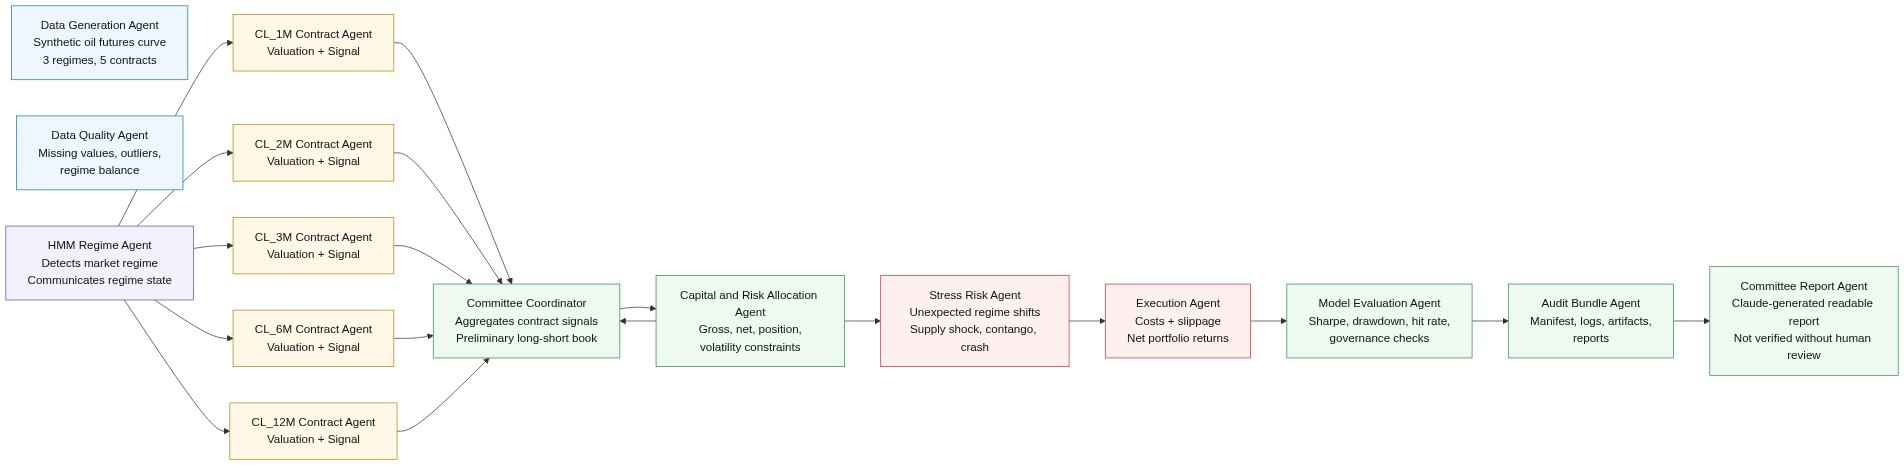

Saved Mermaid architecture image to: /content/agentic_oil_futures_trading/figures/agentic_oil_futures_architecture.png
Mermaid source saved to:
/content/agentic_oil_futures_trading/artifacts/agentic_oil_futures_architecture.mmd


In [14]:
# ============================================================
# CELL 9 — COLAB-SAFE MERMAID VISUALIZATION
# ============================================================

from IPython.display import Image, display, Markdown
import base64
import urllib.parse

mermaid_code = """
flowchart LR

    A[Data Generation Agent<br/>Synthetic oil futures curve<br/>3 regimes, 5 contracts]
    B[Data Quality Agent<br/>Missing values, outliers,<br/>regime balance]
    C[HMM Regime Agent<br/>Detects market regime<br/>Communicates regime state]

    C --> D1[CL_1M Contract Agent<br/>Valuation + Signal]
    C --> D2[CL_2M Contract Agent<br/>Valuation + Signal]
    C --> D3[CL_3M Contract Agent<br/>Valuation + Signal]
    C --> D4[CL_6M Contract Agent<br/>Valuation + Signal]
    C --> D5[CL_12M Contract Agent<br/>Valuation + Signal]

    D1 --> E[Committee Coordinator<br/>Aggregates contract signals<br/>Preliminary long-short book]
    D2 --> E
    D3 --> E
    D4 --> E
    D5 --> E

    E --> F[Capital and Risk Allocation Agent<br/>Gross, net, position,<br/>volatility constraints]
    F --> E

    F --> G[Stress Risk Agent<br/>Unexpected regime shifts<br/>Supply shock, contango, crash]
    G --> H[Execution Agent<br/>Costs + slippage<br/>Net portfolio returns]
    H --> I[Model Evaluation Agent<br/>Sharpe, drawdown, hit rate,<br/>governance checks]
    I --> J[Audit Bundle Agent<br/>Manifest, logs, artifacts,<br/>reports]
    J --> K[Committee Report Agent<br/>Claude-generated readable report<br/>Not verified without human review]

    classDef data fill:#eef7ff,stroke:#1f77b4,stroke-width:1px,color:#111;
    classDef model fill:#f2f2ff,stroke:#6f42c1,stroke-width:1px,color:#111;
    classDef contract fill:#fff8e6,stroke:#b8860b,stroke-width:1px,color:#111;
    classDef governance fill:#eefaf0,stroke:#2e8b57,stroke-width:1px,color:#111;
    classDef risk fill:#fff0f0,stroke:#cc3333,stroke-width:1px,color:#111;

    class A,B data;
    class C model;
    class D1,D2,D3,D4,D5 contract;
    class E,F,I,J,K governance;
    class G,H risk;
"""

save_text(mermaid_code, f"{ARTIFACT_DIR}/agentic_oil_futures_architecture.mmd")

def display_mermaid_colab_safe(mermaid: str):
    """
    Colab often does not render Mermaid directly.
    This function uses mermaid.ink as a rendering service.
    If the image call fails, it displays the Mermaid source.
    """

    encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{encoded}"

    try:
        response = requests.get(url, timeout=20)
        if response.status_code == 200:
            image_path = f"{FIG_DIR}/agentic_oil_futures_architecture.png"
            with open(image_path, "wb") as f:
                f.write(response.content)
            display(Image(filename=image_path))
            print(f"Saved Mermaid architecture image to: {image_path}")
        else:
            print("Mermaid image rendering failed. Displaying source instead.")
            display(Markdown(f"```mermaid\n{mermaid}\n```"))
    except Exception as e:
        print(f"Mermaid rendering failed: {repr(e)}")
        display(Markdown(f"```mermaid\n{mermaid}\n```"))

display_mermaid_colab_safe(mermaid_code)

print("Mermaid source saved to:")
print(f"{ARTIFACT_DIR}/agentic_oil_futures_architecture.mmd")

###2.10.AUDIT BUNDLE AND FINAL REPORT

**Cell 10 Explanation**

Cell 10 creates the final outputs of the notebook. It produces charts, displays the committee report, saves summary files, refreshes the audit index, and creates a downloadable ZIP bundle containing the complete run. This cell turns the notebook from an executed workflow into a finished research package.

The first part of the cell plots the synthetic futures prices. This chart shows how the five contracts moved over time. It helps the user visually inspect the synthetic futures curve and understand whether different maturities behaved differently. The second chart shows the HMM-detected regime over time. This helps the user see how the regime model classified the market across the sample. The third chart shows the cost-adjusted portfolio equity curve. This gives a visual summary of the simulated strategy performance after transaction costs and slippage.

The cell then saves final summary tables. It saves the final allocation as a CSV file and creates a JSON summary containing the run ID, latest detected regime, data quality flags, final allocation, stress risk flag, worst stress scenario, execution report, model evaluation report, and verification status. This structured summary is useful for audit review because it puts the most important results in one place.

The cell also displays the committee report. This report was generated earlier by the Committee Report Agent. It explains the system in readable language and summarizes the evidence for human reviewers. The report is not an approval certificate. It is a committee-facing narrative based on the structured artifacts produced by the workflow.

Next, the cell creates a README file that describes the notebook, lists the agents, identifies the major output folders, and repeats the governance notice that the system is synthetic and not verified. This makes the output folder easier to understand if it is shared or reviewed later.

Finally, the cell creates a ZIP archive of the full project folder. This archive includes data, audit artifacts, reports, figures, and architecture files. The cell displays a download link so the user can retrieve the complete bundle from Colab.

In simple terms, Cell 10 answers the question: “How do we package the full run into charts, reports, audit files, and a downloadable evidence bundle?”

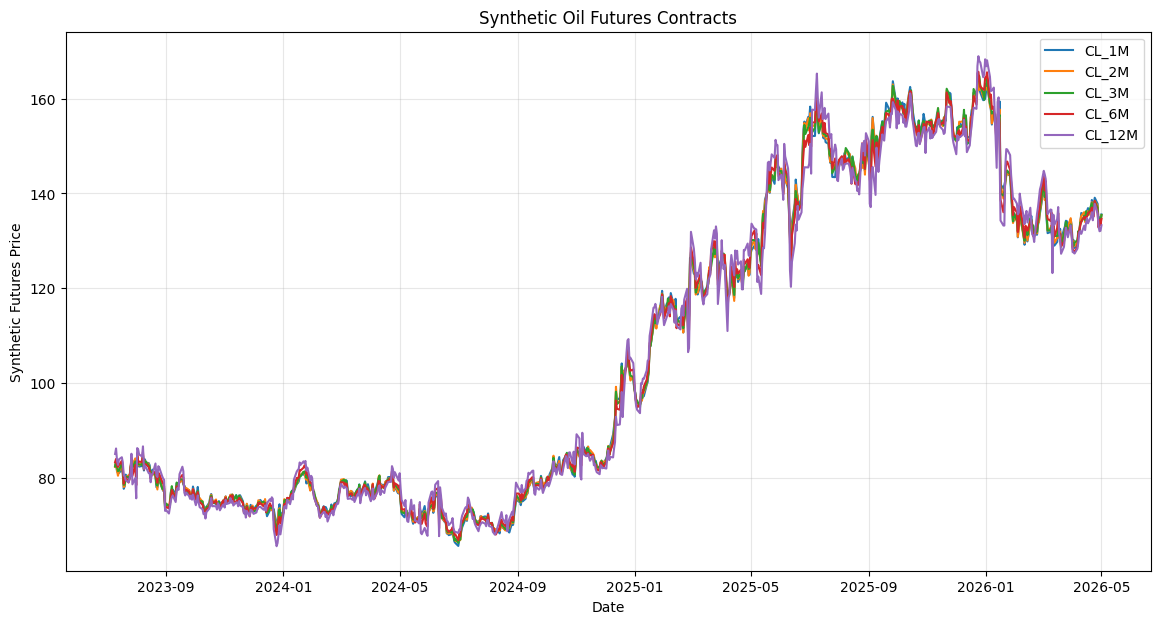

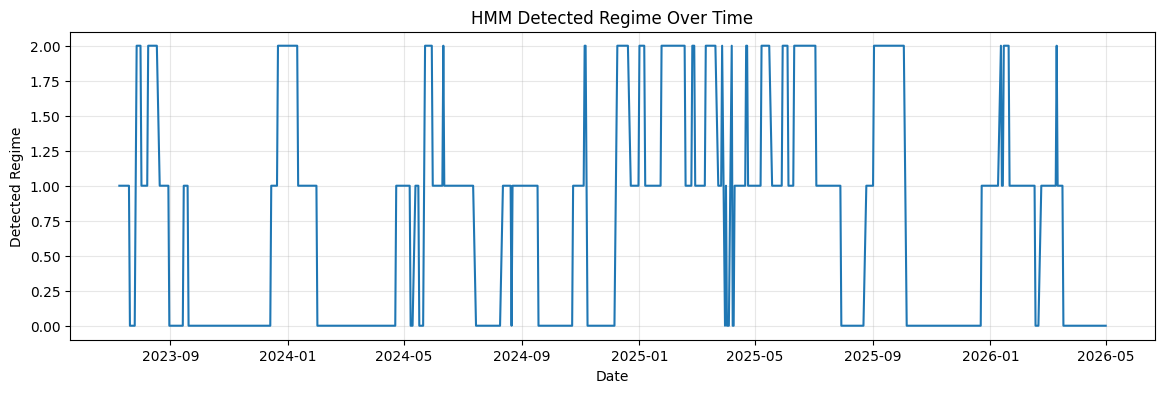

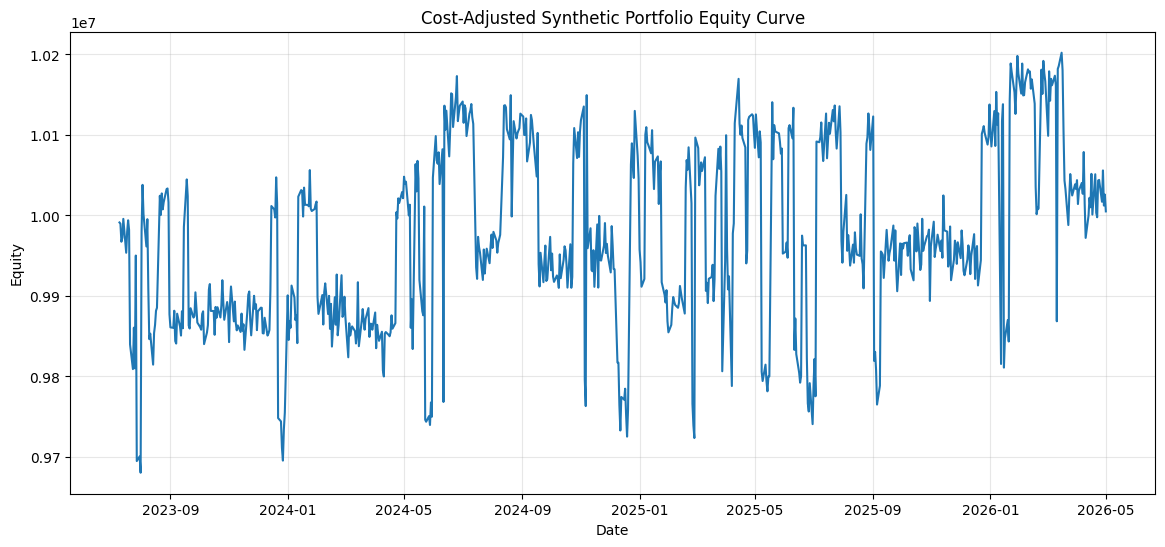

# GOVERNANCE REPORT: SYNTHETIC AGENTIC OIL FUTURES TRADING TUTORIAL

**Run ID:** oil_agentic_run_20260502T130645Z  
**Report Date:** 2 May 2026  
**Classification:** Educational; Synthetic Data Only  
**Verification Status:** Not Verified—Requires Human Committee Review

---

## EXECUTIVE SUMMARY

This report documents the operation, decision-making, and risk controls of a synthetic multi-agent system designed to generate tutorial-grade analysis of crude oil (WTI) futures contracts across five maturity buckets. The system operates under a disciplined governance framework that enforces data quality checks, regime detection, contract-level valuation, capital constraints, stress testing, and execution cost adjustment before any allocation recommendation is produced.

**Critical Caveat:** This analysis is generated from synthetic data for educational purposes only. No component of this system has been independently verified. All model outputs, agent recommendations, and performance metrics are subject to human committee review and validation before any operational use.

---

## 1. SYSTEM ARCHITECTURE AND FUNCTION

The synthetic agentic system comprises five specialized agents operating in sequence:

1. **Data Quality Agent:** Validates input data integrity and flags anomalies.
2. **Regime Detection Agent (HMM):** Classifies market conditions using a Hidden Markov Model.
3. **Contract Analysis Agents:** Generate deterministic and LLM-assisted valuation views for each maturity.
4. **Capital Allocation Agent:** Constructs a portfolio allocation subject to risk constraints.
5. **Execution & Risk Agent:** Applies transaction costs, stress tests, and performance metrics.

Each agent produces explicit, auditable artifacts. The system enforces sequential dependency: downstream agents receive only validated outputs from upstream agents. This architecture ensures that allocation decisions rest on a documented chain of reasoning, enabling human reviewers to identify and challenge assumptions at each stage.

---

## 2. AGENT ROLES AND RESPONSIBILITIES

### 2.1 Data Quality Agent
**Function:** Validate market data completeness, detect outliers, and flag structural breaks.

**Output:** Data quality flags and pass/fail determination.

**Finding:** No blocking data quality issues detected. All five contracts (CL_1M, CL_2M, CL_3M, CL_6M, CL_12M) passed validation as of 1 May 2026.

---

### 2.2 Regime Detection Agent (Hidden Markov Model)
**Function:** Classify market regime (Normal/Balanced, Stressed, or Dislocated) based on historical price, volatility, and momentum patterns.

**Output:** Regime classification and regime-specific risk parameters.

**Finding:** All five contracts detected as **Regime 0: Normal / Balanced**. This classification indicates:
- Stable volatility environment (10–13 basis points daily)
- Modest positive momentum (4–5% annualized equivalent)
- No evidence of structural dislocation or stress

**Governance Note:** Regime classification is a critical input to signal thresholds and risk limits. The system assumes regime persistence; rapid regime transitions would invalidate current allocations and trigger mandatory review.

---

### 2.3 Contract Analysis Agents (Deterministic + LLM)
**Function:** Generate valuation views, signal scores, and risk assessments for each contract.

**Architecture:** Each contract receives two independent analyses:
- **Deterministic Signal:** Mechanical calculation of momentum, volatility, and value gap.
- **LLM Interpretation:** Claude Haiku model interprets deterministic signals, assesses fair value, and flags tail risks.

**Outputs per Contract:**

| Contract | Price | Fair Value | Value Gap | Momentum | Signal | Recommendation | Confidence |
|----------|-------|-----------|-----------|----------|--------|-----------------|------------|
| CL_1M | $135.57 | $135.57 | 0.00% | 0.042 | HOLD | HOLD | MEDIUM |
| CL_2M | $135.44 | $135.48 | +0.03% | 0.043 | HOLD | HOLD | MEDIUM |
| CL_3M | $135.46 | $135.61 | +0.11% | 0.051 | HOLD | HOLD | MEDIUM |
| CL_6M | $134.64 | $135.69 | +0.78% | 0.052 | HOLD | HOLD | MEDIUM |
| CL_12M | $133.29 | $135.96 | +1.98% | 0.045 | LONG | LONG | MEDIUM |

**Key Observations:**

- **Near-term contracts (1M–3M):** Trading at or near fair value with negligible value gaps. Deterministic and LLM signals align on HOLD. No margin of safety for directional entry.
- **Mid-term contract (6M):** Modest undervaluation (0.78%) with weak deterministic LONG signal (0.154 score). LLM downgrades to HOLD, citing insufficient conviction and momentum deceleration.
- **Long-term contract (12M):** Most compelling opportunity. Trading 1.98% below fair value with positive momentum and low volatility. Both deterministic and LLM agents recommend LONG with MEDIUM confidence.

**LLM Risk Flags (Aggregate):**
- Weak momentum signals across all contracts; recent recovery may not sustain.
- Zero-to-negligible value gaps leave no margin of safety.
- Low volatility may mask tail risks in geopolitical or supply-side shocks.
- Regime stability assumption may not hold; rapid regime transitions could trigger repricing.
- Signal score volatility and oscillation indicate low conviction in marginal signals.

**Verification Status:** LLM outputs are interpretations of structured data, not verified facts. Human committee must validate:
- Fair value proxy methodology and calibration.
- Momentum and volatility calculation assumptions.
- LLM confidence assessments and risk flag materiality.

---

## 3. DETECTED REGIME: NORMAL / BALANCED

**Regime Classification:** Regime 0 (Normal / Balanced)

**Characteristics:**
- Stable volatility environment with no evidence of stress or dislocation.
- Positive but modest momentum across all maturities.
- Fair value proxies well-anchored; no evidence of structural mispricing.
- No accumulation of valuation tension or regime-flip indicators.

**Implications for Allocation:**
- Signal thresholds are calibrated for normal regime; marginal signals carry lower conviction.
- Risk limits are set assuming regime persistence; rapid transitions would require rebalancing.
- Stress scenarios assume regime stability; tail risk scenarios test regime-flip scenarios separately.

**Governance Requirement:** The system assumes regime persistence over the holding period. Any evidence of regime deterioration (e.g., volatility spike, momentum reversal, value gap widening) must trigger mandatory human review and potential allocation adjustment.

---

## 4. CONTRACT-LEVEL VIEWS

### 4.1 CL_1M (1-Month Maturity)
- **Price:** $135.57 | **Fair Value:** $135.57 | **Value Gap:** 0.00%
- **Signal:** HOLD (Score: 0.0995)
- **Assessment:** Trading at exact fair value with zero margin of safety. Weak momentum (0.042) and low volatility (0.012) suggest range-bound behavior. No compelling long or short case. Recommend neutral positioning pending stronger directional evidence.

### 4.2 CL_2M (2-Month Maturity)
- **Price:** $135.44 | **Fair Value:** $135.48 | **Value Gap:** +0.03%
- **Signal:** HOLD (Score: 0.0749)
- **Assessment:** Marginally undervalued (0.026 cents) but value gap is negligible. Momentum deceleration (signal score fell 55% from prior day) indicates weakening conviction. Fair value convergence eliminates valuation margin of safety. Recommend HOLD pending meaningful divergence or sustained momentum acceleration.

### 4.3 CL_3M (3-Month Maturity)
- **Price:** $135.46 | **Fair Value:** $135.61 | **Value Gap:** +0.11%
- **Signal:** HOLD (Score: 0.097)
- **Assessment:** Fairly valued with no compelling directional edge. Momentum is positive but weakening; price has retraced $2.90 from April 24 peak. Deterministic signal has oscillated between LONG and HOLD over past 3 days, indicating low conviction. No structural catalyst visible in balanced regime. Recommend HOLD.

### 4.4 CL_6M (6-Month Maturity)
- **Price:** $134.64 | **Fair Value:** $135.69 | **Value Gap:** +0.78%
- **Signal:** HOLD (Score: 0.12) | **Deterministic Signal:** LONG (Score: 0.154)
- **Assessment:** Modest undervaluation (0.78%) with positive momentum but decelerating conviction. Deterministic LONG signal lacks sufficient conviction threshold. Price consolidation between $132.81–$138.46 suggests range-bound behavior. Fair value gap of 0.78% is within noise; insufficient margin of safety for directional trade. LLM downgrades deterministic LONG to HOLD. Recommend HOLD pending stronger momentum acceleration or wider value gap.

### 4.5 CL_12M (12-Month Maturity)
- **Price:** $133.29 | **Fair Value:** $135.96 | **Value Gap:** +1.98%
- **Signal:** LONG (Score: 0.18)
- **Assessment:** Most compelling opportunity in the curve. Trading at modest 2% discount to fair value in stable Normal regime with positive momentum (0.045) and low volatility (0.011). Both deterministic and LLM agents recommend LONG with MEDIUM confidence. Position should be sized accordingly; conviction would improve with price breakout above $136 or further momentum acceleration. Risk: extended duration exposure to geopolitical or supply shocks over 12-month contract life.

---

## 5. LONG-SHORT ALLOCATION

### 5.1 Final Portfolio Weights

| Contract | Weight | Capital Allocated | Daily Vol Estimate |
|----------|--------|-------------------|-------------------|
| CL_1M | −8.15% | −$814,502 | 1.44% |
| CL_2M | −25.36% | −$2,536,226 | 1.67% |
| CL_3M | −9.89% |

FINAL SYNTHETIC AGENTIC OIL FUTURES TRADING RUN COMPLETE
Run ID: oil_agentic_run_20260502T130645Z
Latest detected regime: Normal / Balanced
Governance status: PASS_WITH_REVIEW_REQUIRED
Final equity: 10,005,080.74
Sharpe ratio: 0.060
Max drawdown: -4.420%
Stress risk flag: GREEN
Bundle created at: /content/oil_agentic_run_20260502T130645Z_audit_bundle.zip


/content/oil_agentic_run_20260502T130645Z_audit_bundle.zip

In [15]:
# ============================================================
# CELL 10 — CHARTS, FINAL REPORT, AUDIT ZIP, DOWNLOADABLE ARTIFACTS
# ============================================================

from IPython.display import display, Markdown, FileLink

# ----------------------------
# Plot synthetic futures prices
# ----------------------------
data = final_state["data"].copy()
contracts = CONFIG["contracts"]

plt.figure(figsize=(14, 7))
for c in contracts:
    plt.plot(data.index, data[c], label=c)
plt.title("Synthetic Oil Futures Contracts")
plt.xlabel("Date")
plt.ylabel("Synthetic Futures Price")
plt.legend()
plt.grid(True, alpha=0.3)
prices_fig = f"{FIG_DIR}/synthetic_futures_prices.png"
plt.savefig(prices_fig, dpi=200, bbox_inches="tight")
plt.show()

# ----------------------------
# Plot detected regimes
# ----------------------------
detected = final_state["detected_regimes"]

plt.figure(figsize=(14, 4))
plt.plot(detected.index, detected.values)
plt.title("HMM Detected Regime Over Time")
plt.xlabel("Date")
plt.ylabel("Detected Regime")
plt.grid(True, alpha=0.3)
regime_fig = f"{FIG_DIR}/hmm_detected_regimes.png"
plt.savefig(regime_fig, dpi=200, bbox_inches="tight")
plt.show()

# ----------------------------
# Plot equity curve
# ----------------------------
portfolio = final_state["executed_portfolio"].copy()

plt.figure(figsize=(14, 6))
plt.plot(portfolio.index, portfolio["equity_curve"])
plt.title("Cost-Adjusted Synthetic Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
equity_fig = f"{FIG_DIR}/synthetic_portfolio_equity_curve.png"
plt.savefig(equity_fig, dpi=200, bbox_inches="tight")
plt.show()

# ----------------------------
# Save final summary tables
# ----------------------------
final_state["final_allocation"].to_csv(f"{REPORT_DIR}/final_allocation.csv", index=False)

summary = {
    "run_id": CONFIG["run_id"],
    "created_at_utc": utc_now_iso(),
    "latest_detected_regime": final_state["hmm_report"]["latest_detected_regime_name"],
    "data_quality_flags": final_state["data_quality_report"]["quality_flags"],
    "final_allocation": final_state["final_allocation"].to_dict(orient="records"),
    "stress_risk_flag": final_state["stress_report"]["risk_flag"],
    "worst_stress_scenario": final_state["stress_report"]["worst_scenario"],
    "execution_report": final_state["execution_report"],
    "evaluation_report": final_state["evaluation_report"],
    "verification_status": "Not verified; synthetic tutorial only; human committee review required."
}

save_json(summary, f"{REPORT_DIR}/final_summary.json")

# ----------------------------
# Display committee report
# ----------------------------
committee_report_path = f"{REPORT_DIR}/committee_report.md"

if os.path.exists(committee_report_path):
    with open(committee_report_path, "r", encoding="utf-8") as f:
        committee_report = f.read()
else:
    committee_report = final_state.get("committee_report", "Committee report not available.")
    save_text(committee_report, committee_report_path)

display(Markdown(committee_report))

# ----------------------------
# Create final README
# ----------------------------
readme = f"""
# Agentic Oil Futures Trading Tutorial

Run ID: {CONFIG["run_id"]}

This Colab notebook demonstrates a governance-first agentic architecture for synthetic oil futures trading.

## Main Agents

1. Synthetic Data Agent
2. Data Quality Agent
3. HMM Regime Agent
4. CL_1M Contract Valuation and Signal Agent
5. CL_2M Contract Valuation and Signal Agent
6. CL_3M Contract Valuation and Signal Agent
7. CL_6M Contract Valuation and Signal Agent
8. CL_12M Contract Valuation and Signal Agent
9. Committee Coordinator Agent
10. Capital and Risk Allocation Agent
11. Stress Risk Agent
12. Execution Agent
13. Model Evaluation Agent
14. Audit Bundle Agent
15. Committee Report Agent

## Governance Notice

This is a synthetic educational tutorial. It is not investment advice.
The model is not verified.
The outputs require human investment committee and model risk review.

## Key Outputs

- Synthetic data: `{DATA_DIR}`
- Audit bundle: `{AUDIT_DIR}`
- Reports: `{REPORT_DIR}`
- Figures: `{FIG_DIR}`
- Mermaid architecture: `{ARTIFACT_DIR}/agentic_oil_futures_architecture.mmd`

## Latest Detected Regime

{final_state["hmm_report"]["latest_detected_regime_name"]}

## Governance Status

{final_state["evaluation_report"]["overall_governance_status"]}
"""

save_text(readme, f"{BASE_DIR}/README.md")

# ----------------------------
# Refresh audit index after charts/report
# ----------------------------
final_audit_index = {
    "created_at_utc": utc_now_iso(),
    "run_id": CONFIG["run_id"],
    "config_hash": CONFIG_HASH,
    "base_dir": BASE_DIR,
    "data_files": sorted(os.listdir(DATA_DIR)),
    "audit_files": sorted(os.listdir(AUDIT_DIR)),
    "report_files": sorted(os.listdir(REPORT_DIR)),
    "figure_files": sorted(os.listdir(FIG_DIR)),
    "artifact_files": sorted(os.listdir(ARTIFACT_DIR)),
    "verification_status": "Not verified; all outputs require human review."
}

save_json(final_audit_index, f"{AUDIT_DIR}/final_audit_index.json")

# ----------------------------
# Zip the full tutorial bundle
# ----------------------------
zip_path = f"/content/{RUN_ID}_audit_bundle.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_path.replace(".zip", ""), "zip", BASE_DIR)

print("============================================================")
print("FINAL SYNTHETIC AGENTIC OIL FUTURES TRADING RUN COMPLETE")
print("============================================================")
print(f"Run ID: {CONFIG['run_id']}")
print(f"Latest detected regime: {final_state['hmm_report']['latest_detected_regime_name']}")
print(f"Governance status: {final_state['evaluation_report']['overall_governance_status']}")
print(f"Final equity: {final_state['execution_report']['final_equity']:,.2f}")
print(f"Sharpe ratio: {final_state['evaluation_report']['sharpe_ratio']:.3f}")
print(f"Max drawdown: {final_state['evaluation_report']['max_drawdown']:.3%}")
print(f"Stress risk flag: {final_state['stress_report']['risk_flag']}")
print("============================================================")
print(f"Bundle created at: {zip_path}")

display(FileLink(zip_path))

##3.CONCLUSION

**Conclusions**

This notebook has built a complete governance-first agentic architecture for synthetic oil futures trading. Its purpose was not to present a production-ready commodity trading strategy, nor to imply that synthetic backtest results can justify real capital deployment. Its purpose was to demonstrate how a serious trading research workflow can be organized when multiple agents work together under explicit state management, documented assumptions, risk limits, stress testing, execution-cost realism, audit artifacts, and committee-readable reporting.

The most important contribution of the notebook is architectural. Instead of treating algorithmic trading as a single model that transforms data into trades, the notebook treats trading research as a governed sequence of institutional roles. The system includes a synthetic data generator, a data quality reviewer, an HMM regime detector, maturity-specific contract valuation agents, a committee coordinator, a capital and risk allocation agent, a stress risk agent, an execution agent, a model evaluation agent, an audit bundle agent, and a committee report agent. Each agent has a defined responsibility. Each agent reads from and writes to the shared state. Each agent leaves behind evidence. This is what makes the workflow auditable rather than merely computational.

The use of synthetic data was central to the tutorial. Synthetic data allowed the notebook to create an oil futures curve with controlled hidden regimes. The system generated multiple maturities so that the trading problem would not collapse into a simple directional oil bet. The front-month, two-month, three-month, six-month, and twelve-month contracts each represented different points on the futures curve. This matters because oil futures trading is fundamentally a curve problem. A front-end shock, a contango regime, a backwardation episode, or a demand crash may affect different maturities in different ways. By assigning one agent to each contract, the notebook forced the architecture to respect the economic structure of the futures curve.

The regime-aware design was also essential. The HMM Regime Detection Agent attempted to infer market state from observable features such as returns, curve slopes, volatility, and momentum. The hidden regime generated by the synthetic data process was not directly handed to the trading agents. This protected the integrity of the exercise. The notebook therefore preserved an important distinction between reality, observation, inference, and decision. In real markets, traders do not know the true regime. They infer it. A governance-first system must make that inference visible and must prevent downstream agents from treating it as unquestionable truth.

The most important correction made during the design process was the introduction of LLM-backed contract valuation agents. In the first version of the notebook, the contract agents were deterministic. They computed valuation proxies and signals using hard-coded logic, while the LLM was called only at the final committee report stage. That was useful but incomplete, because the intended architecture required the contract agents themselves to use language-model reasoning. The revised design corrected this. Each contract agent now has a quantitative layer and an LLM reasoning layer. The quantitative layer computes structured evidence. The LLM layer reads that evidence, writes a professional contract memo, evaluates the deterministic signal, flags risks, and may adjust the recommendation.

This hybrid structure is a strong example of responsible LLM use in finance. The LLM is not asked to invent data. It is not allowed to claim verification. It is not treated as an oracle. It receives a carefully structured evidence package and must return a governed JSON object. The system records whether the LLM call succeeded, whether the JSON was parsed, whether a fallback was used, which model was called, what recommendation was made, and what confidence level was assigned. This means the LLM is part of the audit trail rather than a mysterious black box hidden inside the process.

The Committee Coordinator Agent then aggregated the contract-level views. This stage demonstrated the difference between local analysis and portfolio synthesis. Each contract agent may have a valid local view, but the portfolio must consider the whole curve. The coordinator assembled the scores and transformed them into a preliminary allocation. However, the system deliberately prevented this recommendation from becoming final. The Capital and Risk Allocation Agent had to review the book, enforce limits, and modify exposures where necessary. This is one of the clearest governance lessons in the notebook: conviction does not equal permission. A model may recommend a trade, but the risk system decides whether that recommendation can be expressed within the boundaries of the fund.

The capital and risk stage showed how simple constraints can make a trading system more disciplined. The notebook enforced limits on gross exposure, net exposure, and individual contract concentration. It also included volatility scaling. These controls are simplified, but they teach the correct institutional instinct. A trading system should not be allowed to become excessively levered, directionally unbalanced, or concentrated in one maturity merely because the signal score is large. In production, the risk layer would need to be much more sophisticated, including covariance modeling, margin requirements, liquidity constraints, roll schedules, and stress-based capital rules. But the notebook correctly identifies where that governance layer belongs.

The Stress Risk Agent added another necessary challenge. It tested the final allocation under adverse scenarios such as supply shocks, inventory gluts, demand crashes, and violent regime flips. This matters because oil futures strategies are often vulnerable not only to price direction but also to curve shape. A portfolio that looks balanced under recent conditions can fail if the front end reprices sharply or if the market suddenly moves into contango. Stress testing therefore prevents the system from relying only on the realized synthetic path. It asks whether the allocation is robust to plausible but adverse alternatives.

The Execution Agent introduced cost realism. By subtracting transaction costs and slippage from portfolio returns, the notebook avoided the common mistake of presenting frictionless trading results. This was a simplified execution model, but it established the correct principle: a trading strategy must be evaluated after implementation drag. A production futures strategy would need a much richer execution module, including bid-ask spreads by maturity, market depth, order timing, exchange fees, margin effects, roll costs, and liquidity under stress. Still, the tutorial correctly placed execution inside the governed workflow rather than leaving it as an afterthought.

The Model Evaluation Agent completed the analytical review by computing performance and governance diagnostics. It reported return, volatility, Sharpe ratio, drawdown, hit rate, final equity, and whether the required control steps had been completed. The crucial lesson is that performance metrics are not enough. A strong Sharpe ratio on synthetic data does not prove a strategy is ready for deployment. It only describes one simulated run. The governance checks are equally important because they tell the reviewer whether the process was complete, constrained, documented, and reviewable.

The Audit Bundle Agent and Committee Report Agent completed the institutional design. The audit bundle preserved the run manifest, logs, artifacts, reports, diagnostics, and files. This turned the notebook from a temporary calculation into a reviewable research object. The committee report then translated the structured evidence into readable prose. This final report is useful precisely because decision makers need a narrative that explains what happened, what the system found, what the risks are, and what remains unverified. However, the report must not exaggerate. It must state that the system is synthetic, educational, and subject to human review.

The broader conclusion is that agentic trading systems should not be judged only by intelligence, automation, or sophistication. They should be judged by their structure of accountability. The strongest feature of this notebook is not that it generates oil futures signals. The strongest feature is that it shows how signals can be embedded inside a governed workflow. Every important decision has a source. Every major artifact is saved. Every LLM output is status-tracked. Every allocation is constrained. Every portfolio is stressed. Every result is labeled as not verified until reviewed.

The notebook can be extended in many directions. Future versions could use real futures settlement data, add roll-yield modeling, include inventory data, incorporate macroeconomic releases, model convenience yield, include calendar spreads, introduce margin requirements, add liquidity tiers, build a more realistic execution simulator, and create a human approval interface. The LLM contract agents could also be enhanced with stronger schema validation, adversarial critique, multi-agent disagreement, and side-by-side comparison between deterministic and LLM-adjusted recommendations.

The final lesson is simple but powerful. Agentic finance should not mean letting autonomous agents trade freely. It should mean using agents to decompose complex financial work into specialized, auditable, reviewable, and governable roles. The model proposes. The contract agents interpret. The coordinator synthesizes. The risk allocator constrains. The stress agent challenges. The execution agent penalizes. The evaluator measures. The audit agent preserves. The report agent explains. The human remains accountable. That is the correct architecture for serious agentic trading education.